# H-CAST Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares:

- baseline `/scratch/g.saggini1/outputs/hcast_cifar100`
- temperature variants from runs matching `/scratch/g.saggini1/outputs/hcast_hcc_cifar100*`

It includes:
- validation curves for `fpa_topdown` and `weighted_ap_topdown`,
- per-level validation top-down accuracy curves,
- a final test comparison table with deltas,
- projection diagnostics (`proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, etc.),
- short interpretation snippets after each analysis block.


In [31]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import HCastAnalysis, HCastAnalysisConfig, resolve_project_root

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [32]:
INCLUDE_BASELINES = True
BASELINE_COLOR = '#1f77b4'

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hcast_cifar100', 'label': 'H-CAST'},
    'cub-200-2011': {'run_dir': 'hcast_cub200', 'label': 'H-CAST'},
    'fgvc-aircraft': {'run_dir': 'hcast_aircraft', 'label': 'H-CAST'},
}

MANUAL_RUNS = [
    # CIFAR100
    #{'run_dir': 'hcast_cifar100_nomixup_nosmoothing', 'label': 'HCAST nomixup nosmoothing'},
    #{'run_dir': 'hcast_cifar100_nokl', 'label': 'HCAST nokl'},
    {'run_dir': 'hcast_lex_cifar100', 'label': 'HCAST lex'},
    {'run_dir': 'hcast_lex_cifar100_step_80epoch', 'label': 'HCAST lex step epoch 80'},
    # {'run_dir': 'hcast_hcc_cifar100_step_80epoch', 'label': 'HCC step epoch 80'},
    # {'run_dir': 'hcast_hcc_cifar100_step_80epoch_nokl', 'label': 'HCC step epoch 80 nokl'},
    {'run_dir': 'hcast_hcc_cifar100_step_0epoch', 'label': 'HCC step epoch 0'},
    # {'run_dir': 'hcast_hcc_cifar100_step_0epoch_nokl', 'label': 'HCC step epoch 0 nokl'},
    # CUB200
    #{'run_dir': 'hcast_cub200_nokl', 'label': 'HCAST nokl'},
    {'run_dir': 'hcast_lex_cub200', 'label': 'HCAST lex'},
    {'run_dir': 'hcast_lex_cub200_step_80epoch', 'label': 'HCAST lex step epoch 80'},
    # {'run_dir': 'hcast_hcc_cub200_step_80epoch', 'label': 'HCC step epoch 80'},
    # {'run_dir': 'hcast_hcc_cub200_step_80epoch_nokl', 'label': 'HCC step epoch 80 nokl'},
    # {'run_dir': 'hcast_hcc_cub200_step_0epoch', 'label': 'HCC step epoch 0'},
    # {'run_dir': 'hcast_hcc_cub200_step_0epoch_nokl', 'label': 'HCC step epoch 0 nokl'},
    # Aircraft
    #{'run_dir': 'hcast_aircraft_nokl', 'label': 'HCAST nokl'},
    {'run_dir': 'hcast_lex_aircraft', 'label': 'HCAST lex'},
    {'run_dir': 'hcast_lex_aircraft_step_80epoch', 'label': 'HCAST lex step epoch 80'},
    {'run_dir': 'hcast_hcc_aircraft_step_80epoch', 'label': 'HCC step epoch 80'},
    # {'run_dir': 'hcast_hcc_aircraft_step_80epoch_nokl', 'label': 'HCC step epoch 80 nokl'},
    # {'run_dir': 'hcast_hcc_aircraft_step_0epoch', 'label': 'HCC step epoch 0'},
    # {'run_dir': 'hcast_hcc_aircraft_step_0epoch_nokl', 'label': 'HCC step epoch 0 nokl'},
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [33]:
config = HCastAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HCastAnalysis.from_config(config)
analysis.print_run_summary()


Using baseline key cub200 for dataset key cub2002011
[cifar-100] H-CAST: epochs=100, best_td_epoch=93, best_ind_epoch=93, baseline
[cifar-100] HCAST lex: epochs=100, best_td_epoch=93, best_ind_epoch=93
[cifar-100] HCAST lex step epoch 80: epochs=100, best_td_epoch=93, best_ind_epoch=93
[cifar-100] HCC step epoch 0: epochs=100, best_td_epoch=93, best_ind_epoch=90, T=10
[cub-200-2011] H-CAST: epochs=100, best_td_epoch=99, best_ind_epoch=97, baseline
[cub-200-2011] HCAST lex: epochs=100, best_td_epoch=92, best_ind_epoch=92
[cub-200-2011] HCAST lex step epoch 80: epochs=100, best_td_epoch=45, best_ind_epoch=73
[fgvc-aircraft] H-CAST: epochs=100, best_td_epoch=97, best_ind_epoch=95, baseline
[fgvc-aircraft] HCAST lex: epochs=100, best_td_epoch=82, best_ind_epoch=97
[fgvc-aircraft] HCAST lex step epoch 80: epochs=100, best_td_epoch=79, best_ind_epoch=79
[fgvc-aircraft] HCC step epoch 80: epochs=100, best_td_epoch=96, best_ind_epoch=96, T=10


## H-CAST Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


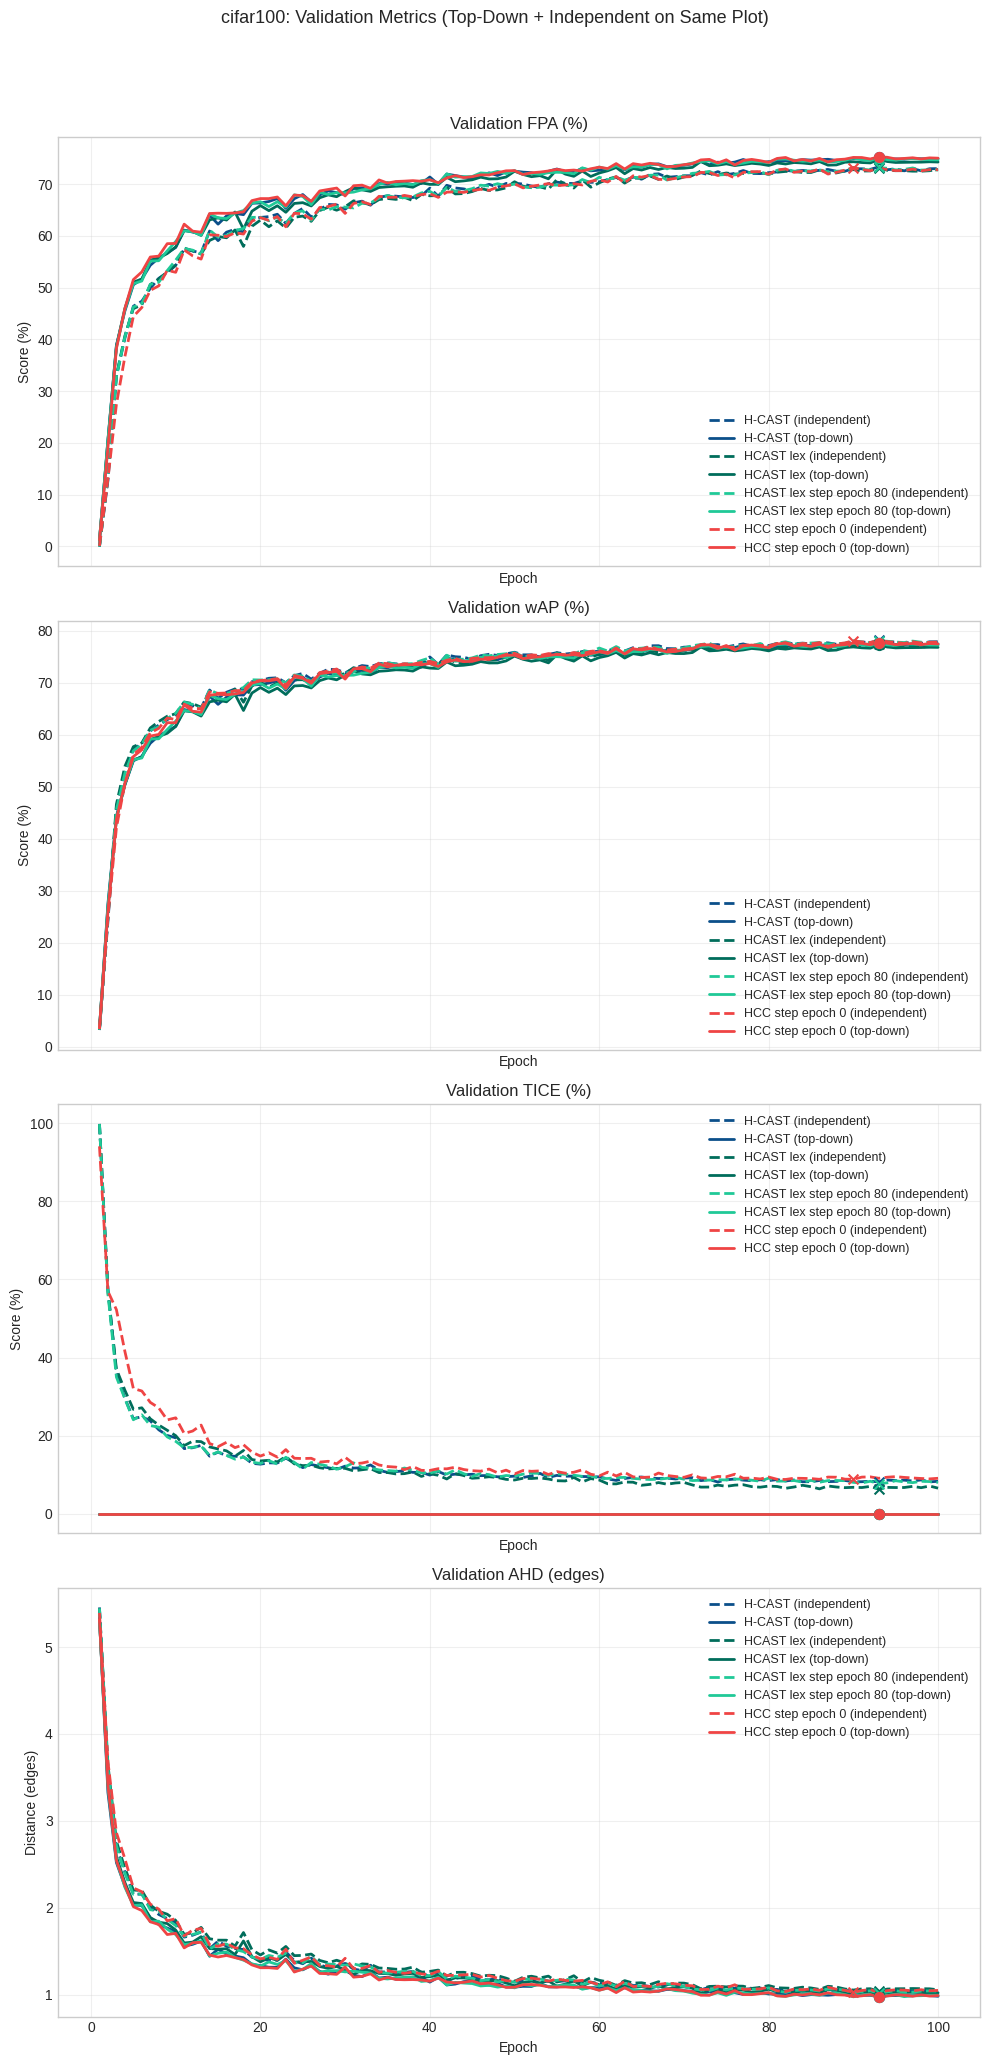

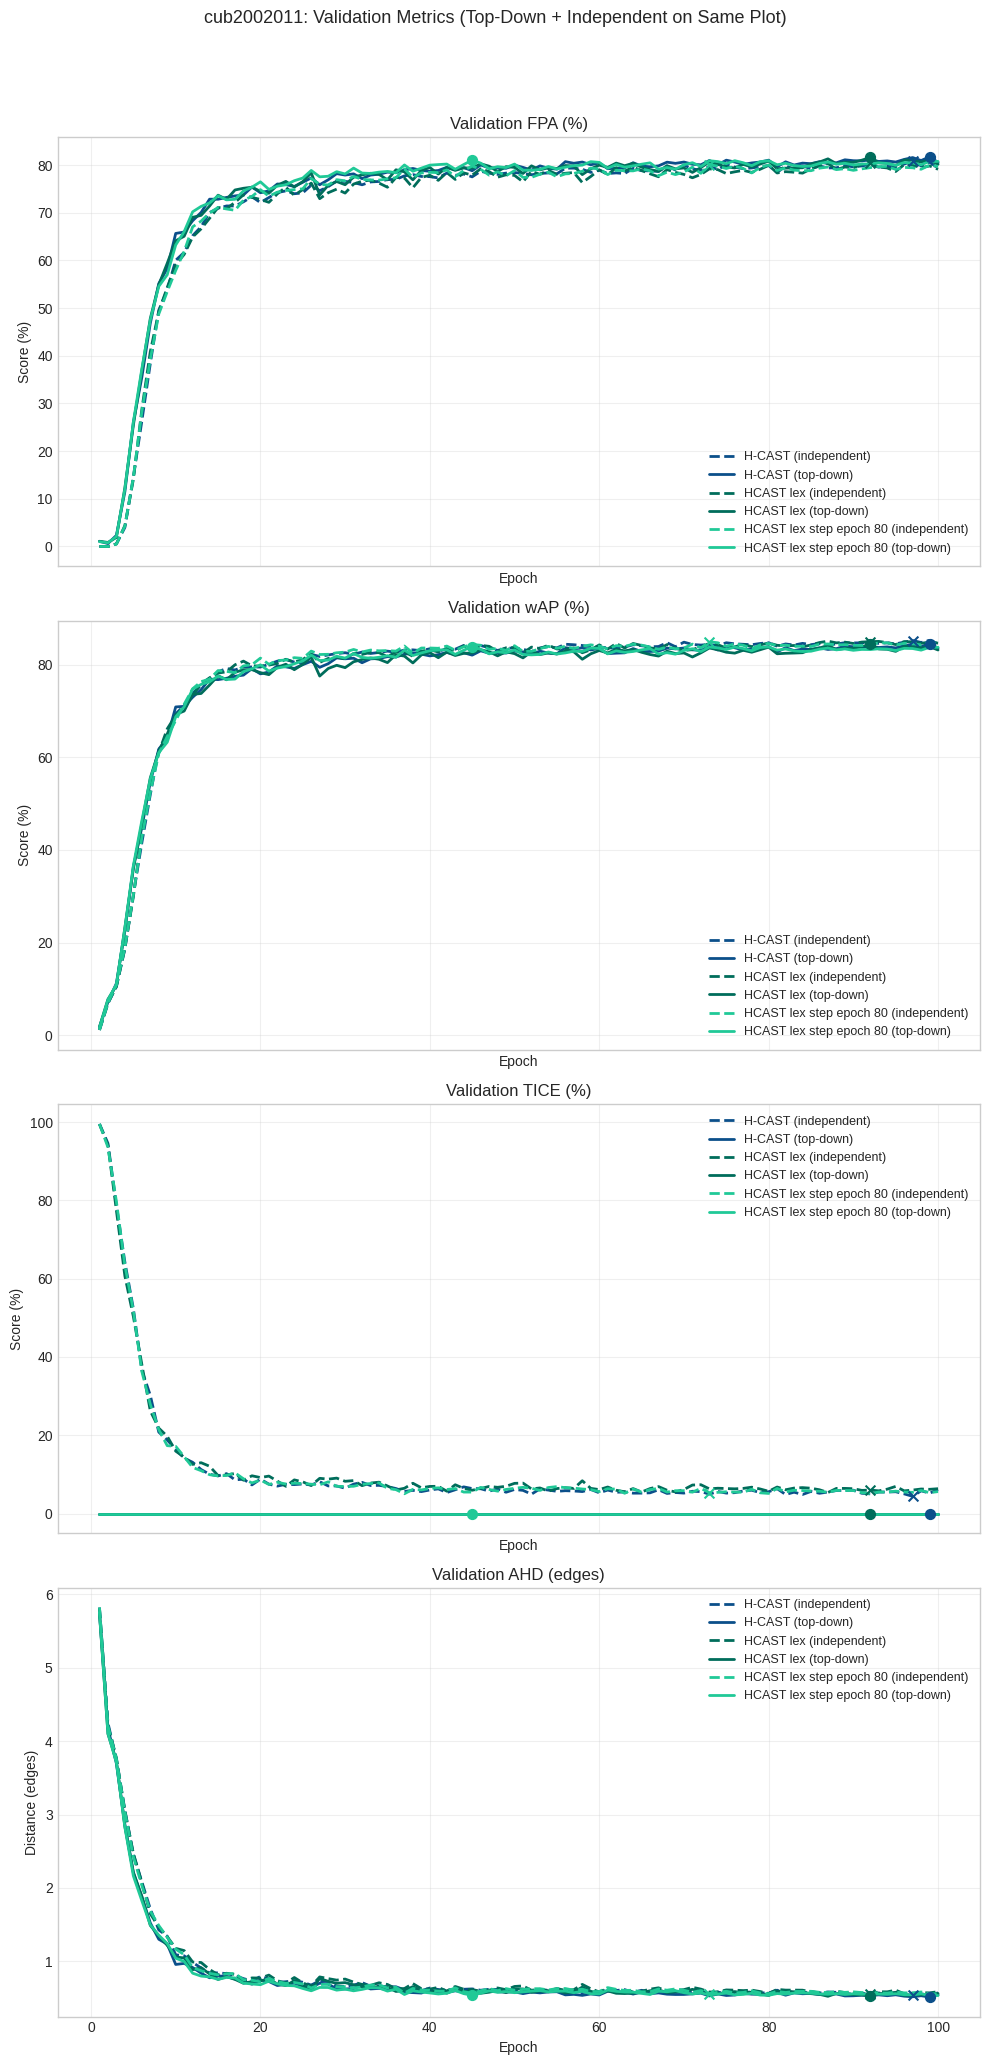

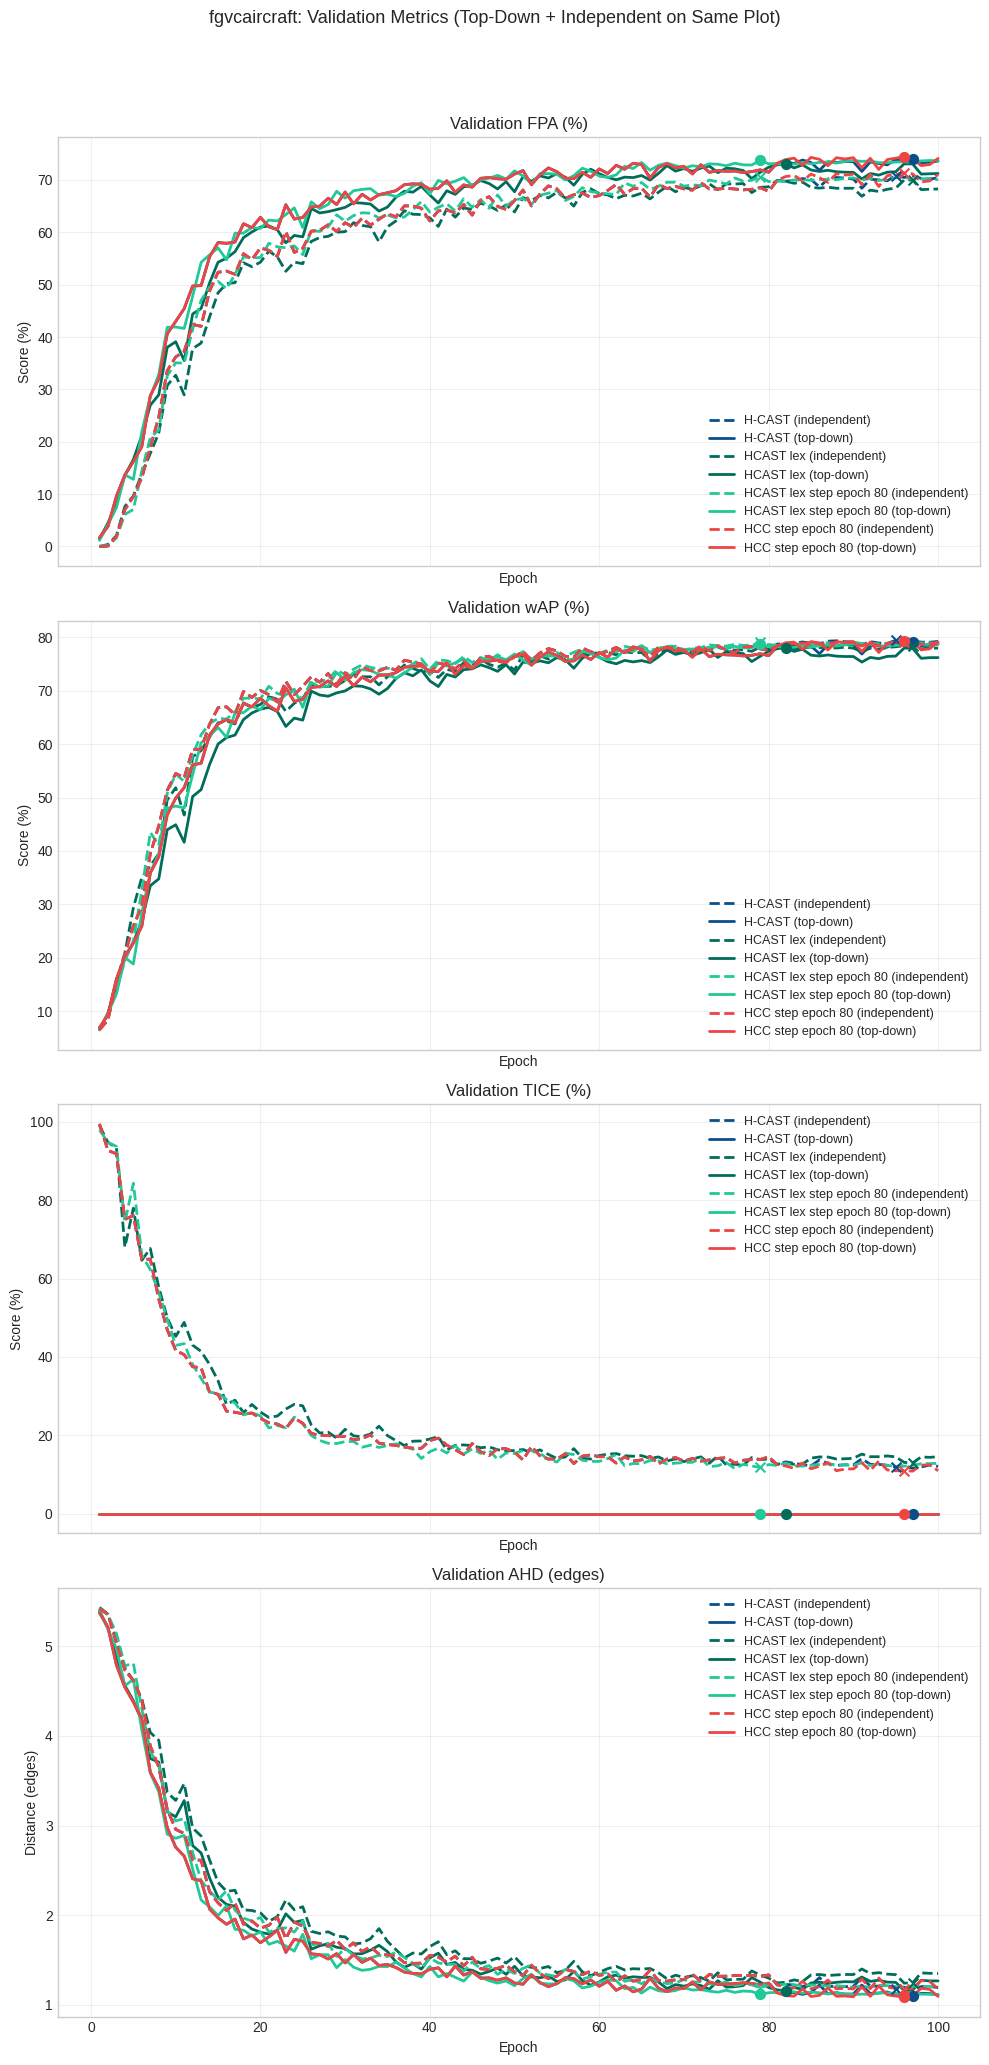

In [34]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (HCC)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha` (annealing blend/schedule value),
- `proj_constraint_strength` (intrinsic projection strength),
- `proj_temperature`,
- `proj_mode_intrinsic_soft`.


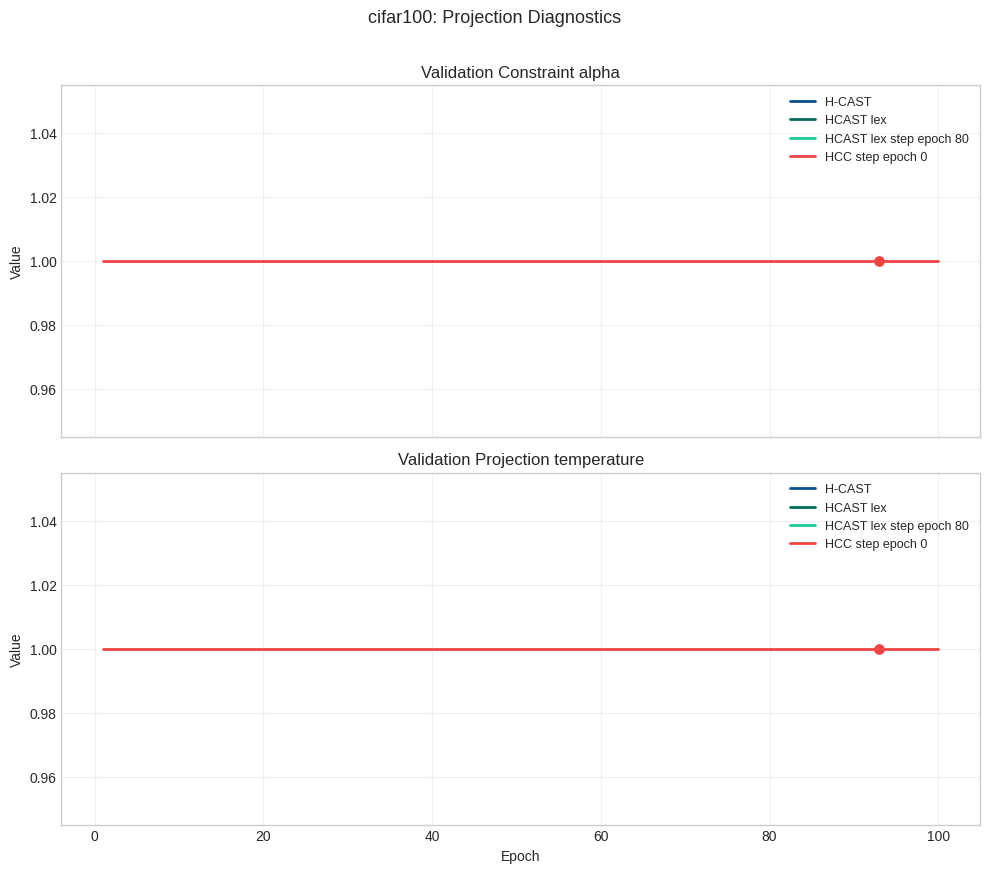

[cub2002011] No projection diagnostics found in selected runs.


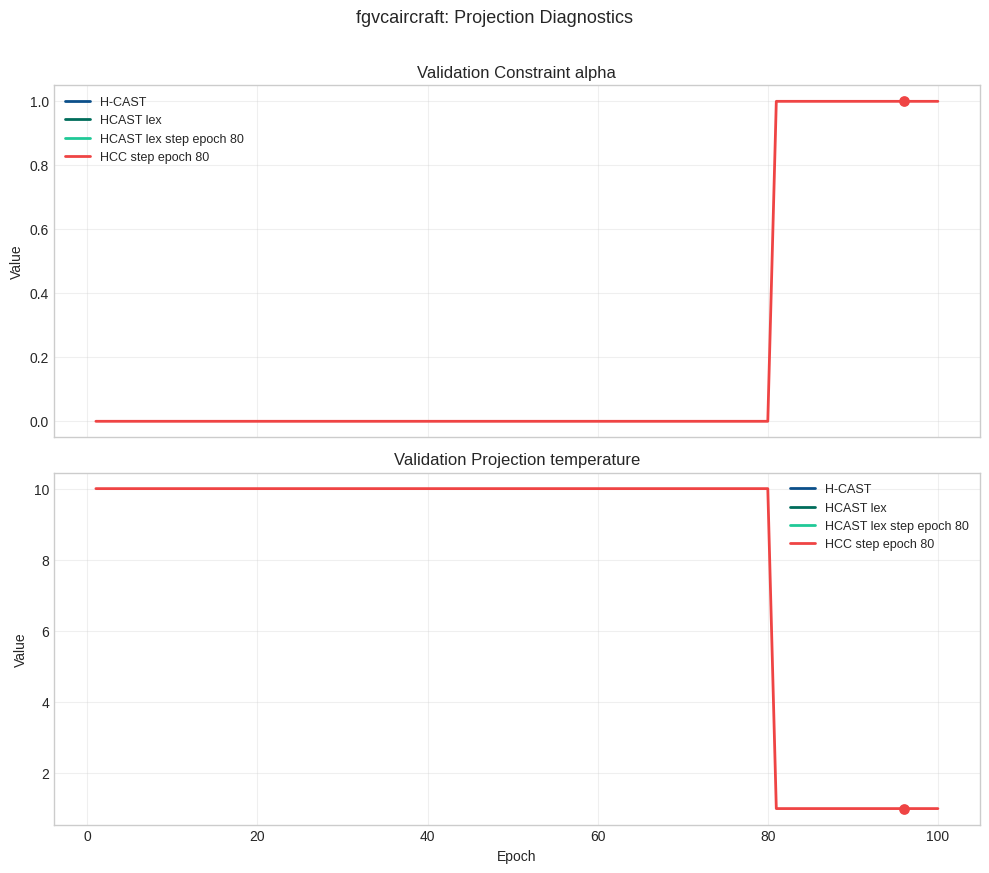

In [35]:
analysis.plot_projection_diagnostics()


## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`) and per-level losses (`loss_level_*`).

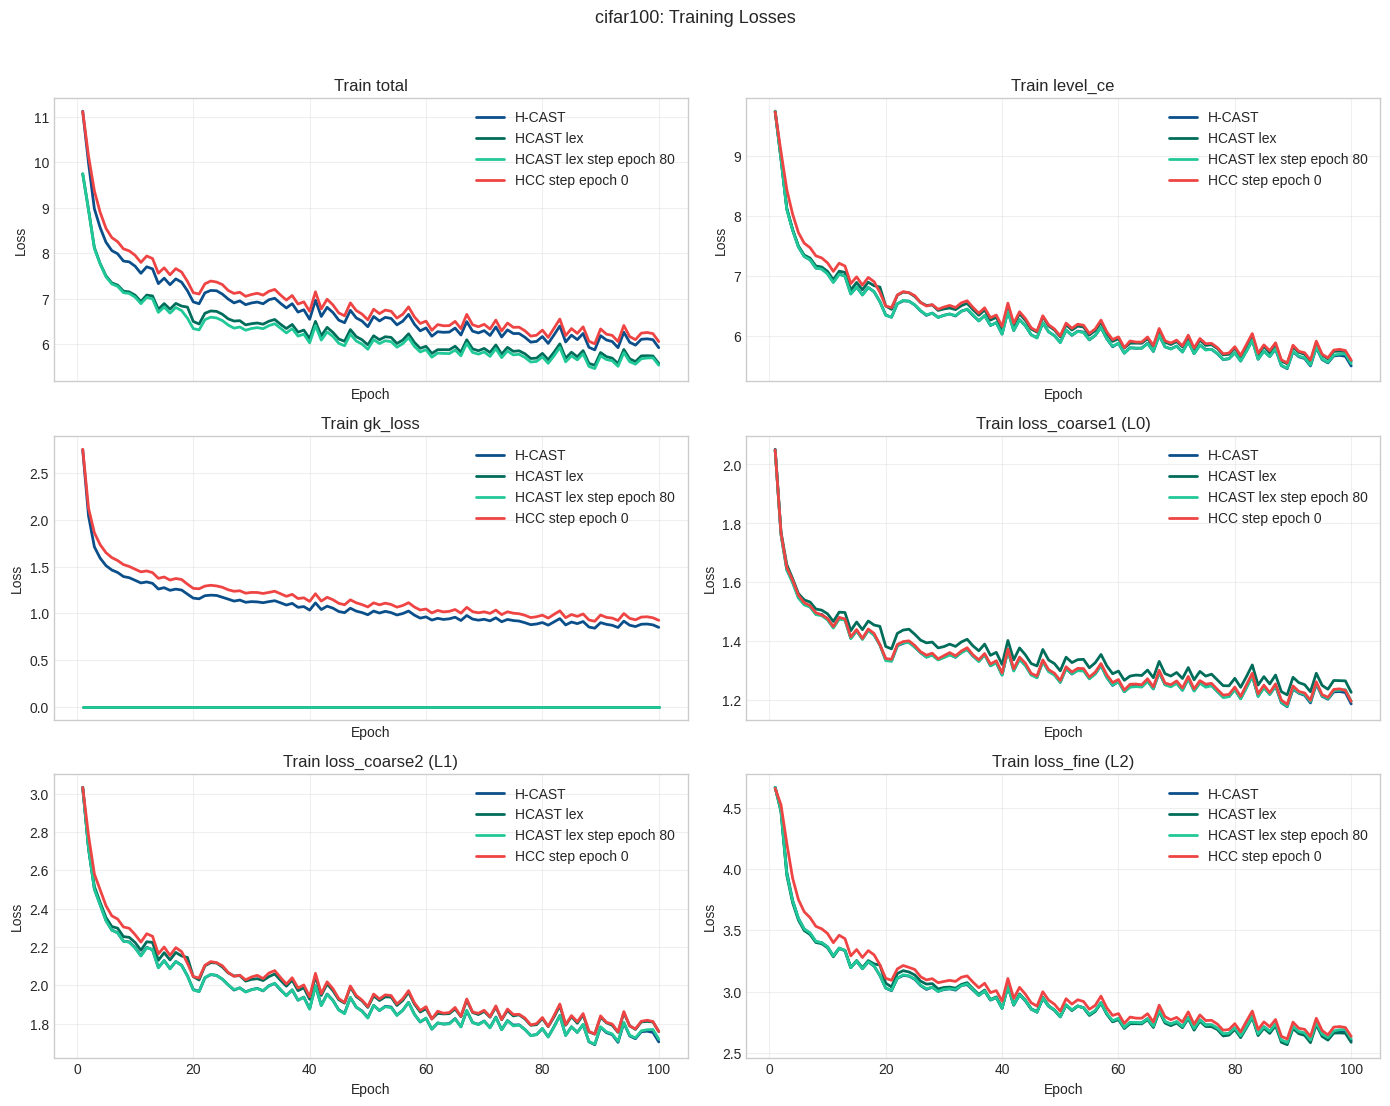

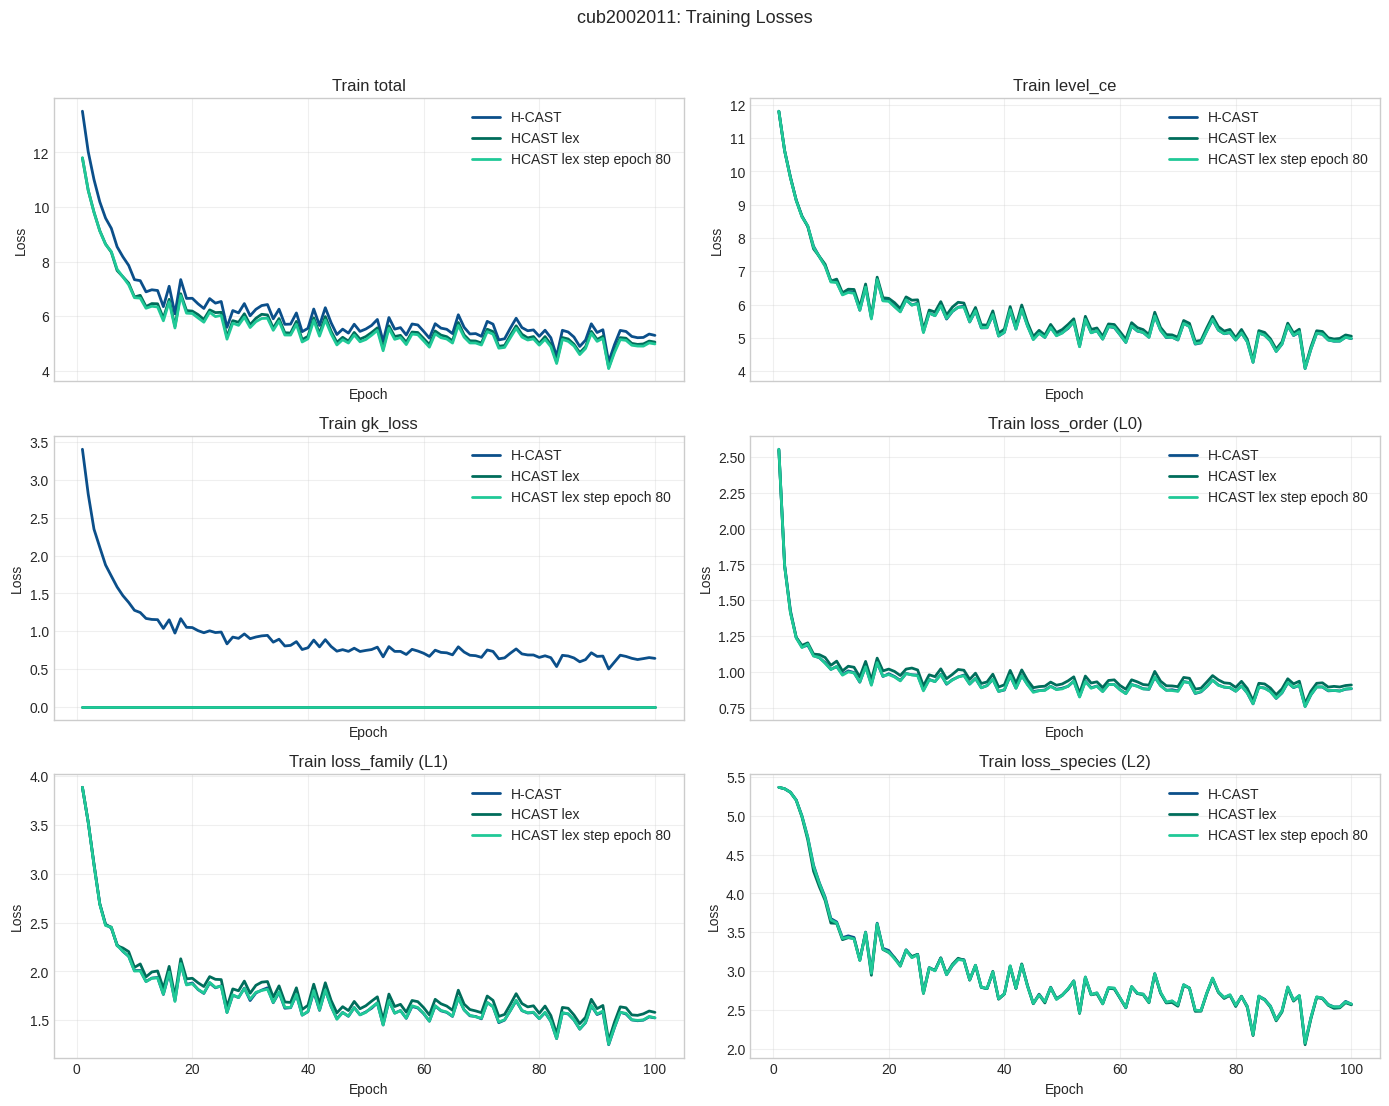

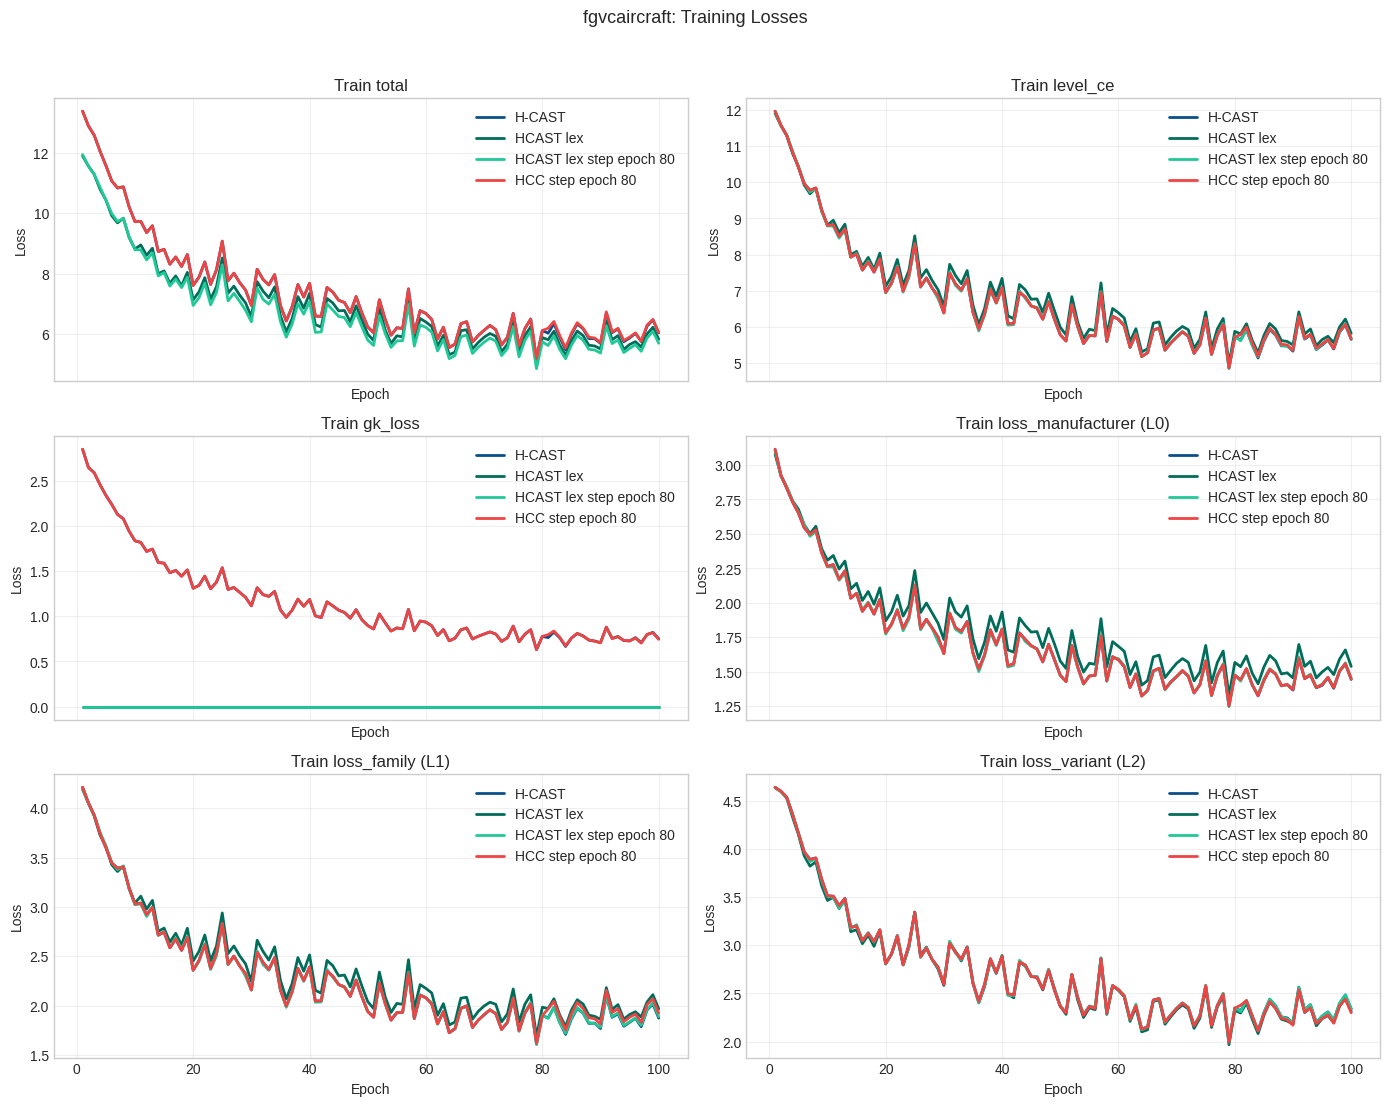

In [36]:
analysis.plot_training_losses()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



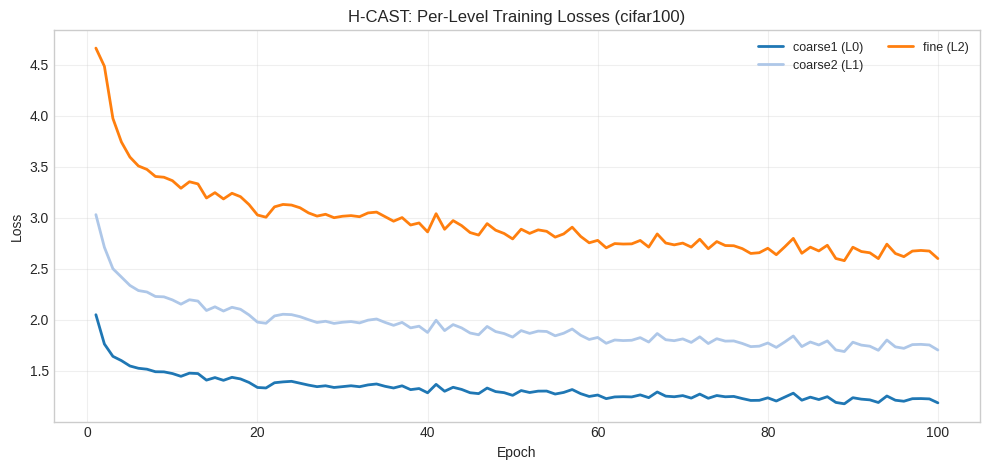

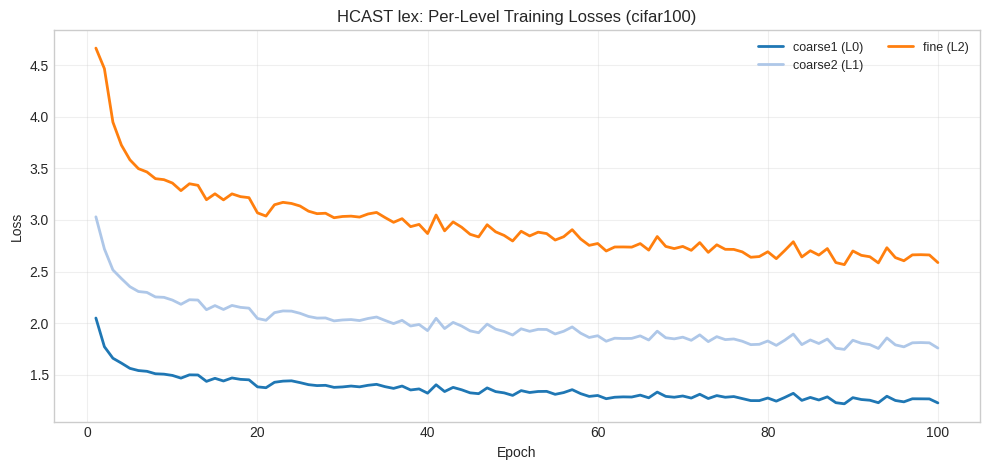

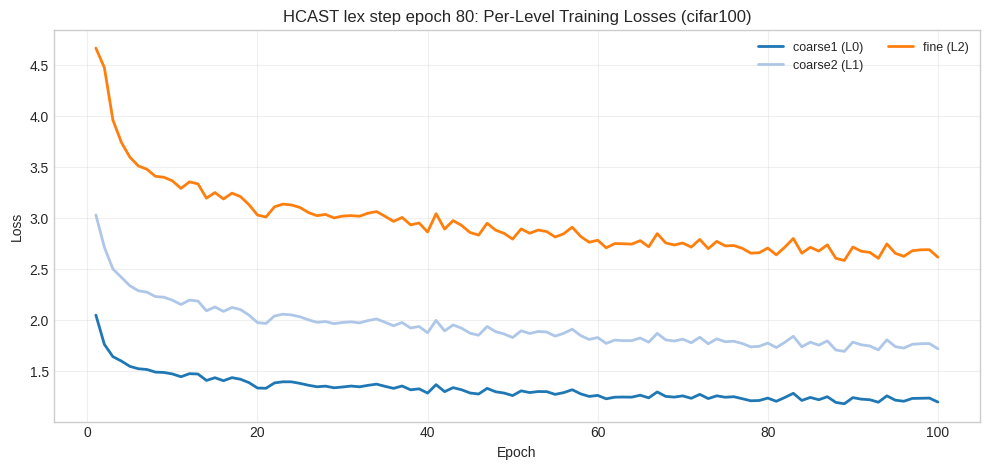

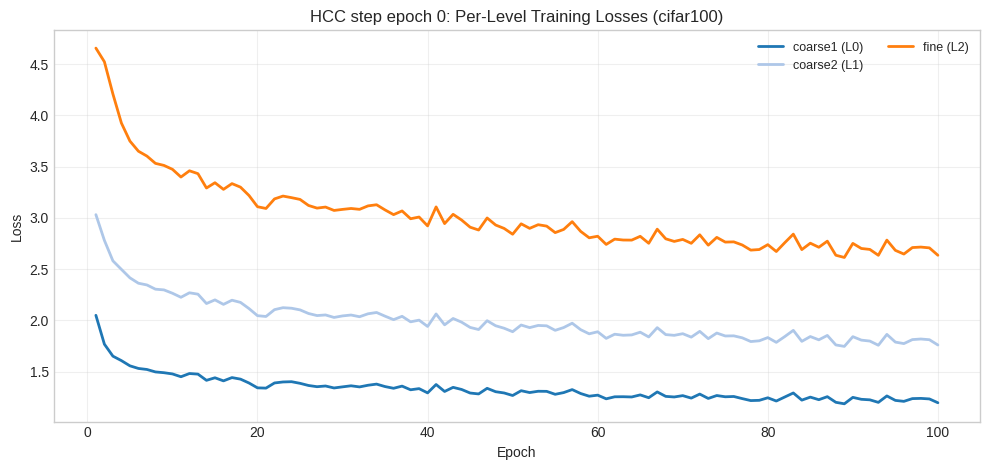

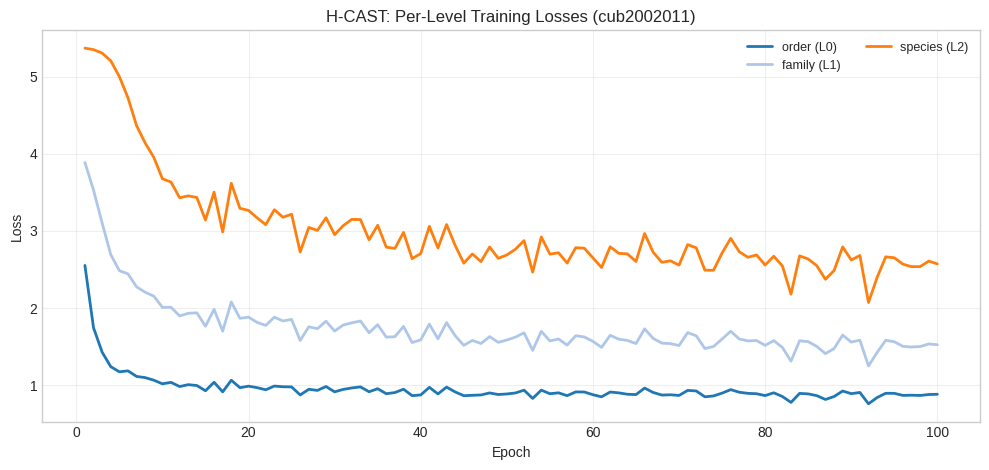

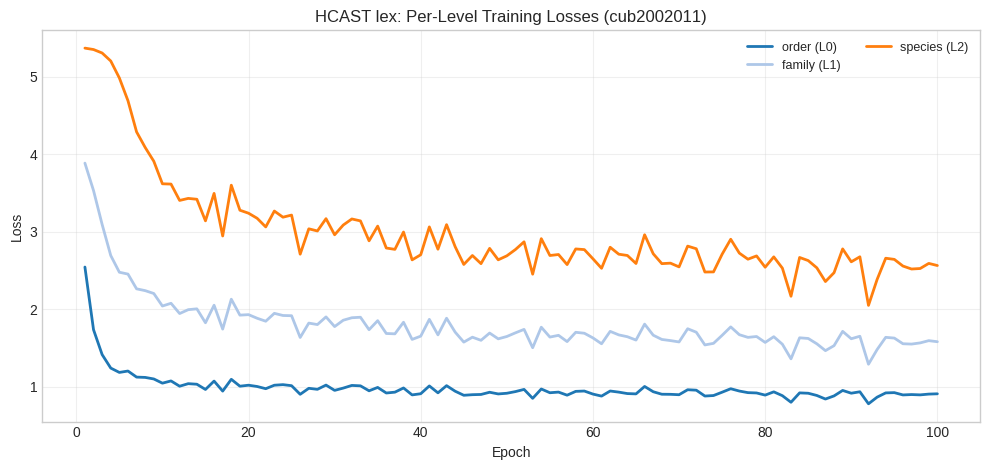

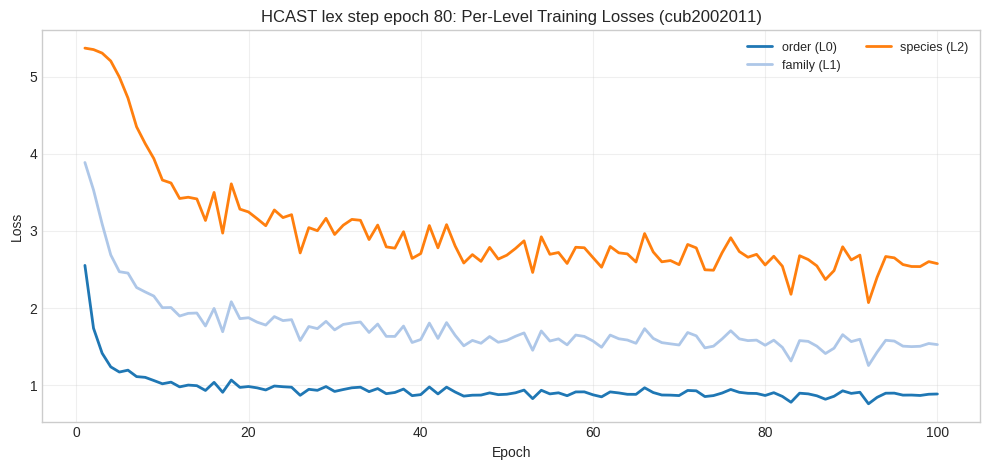

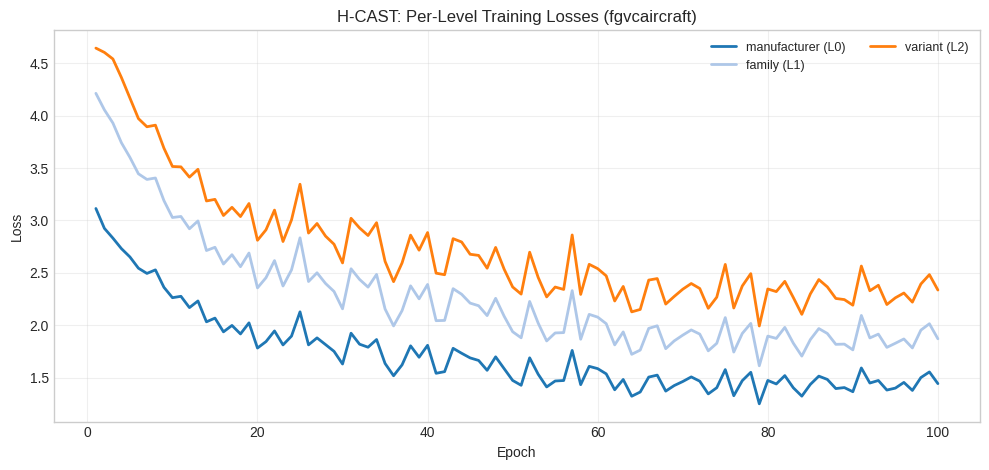

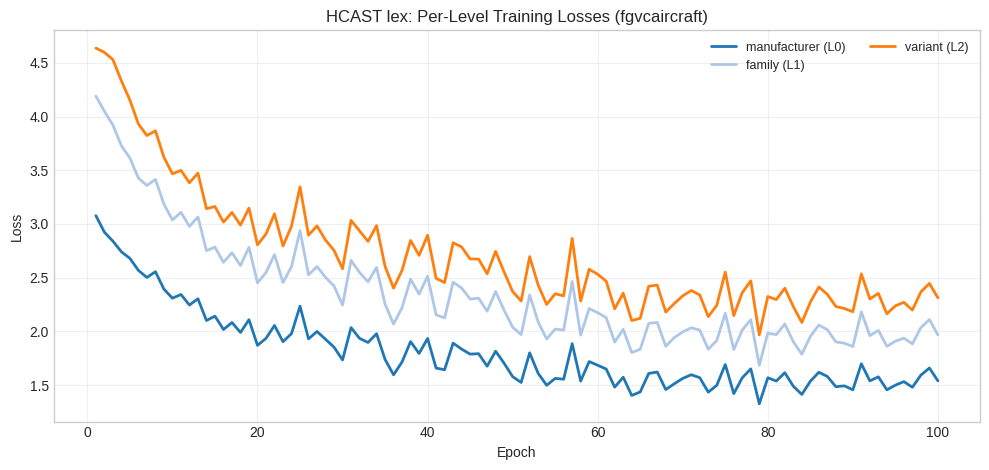

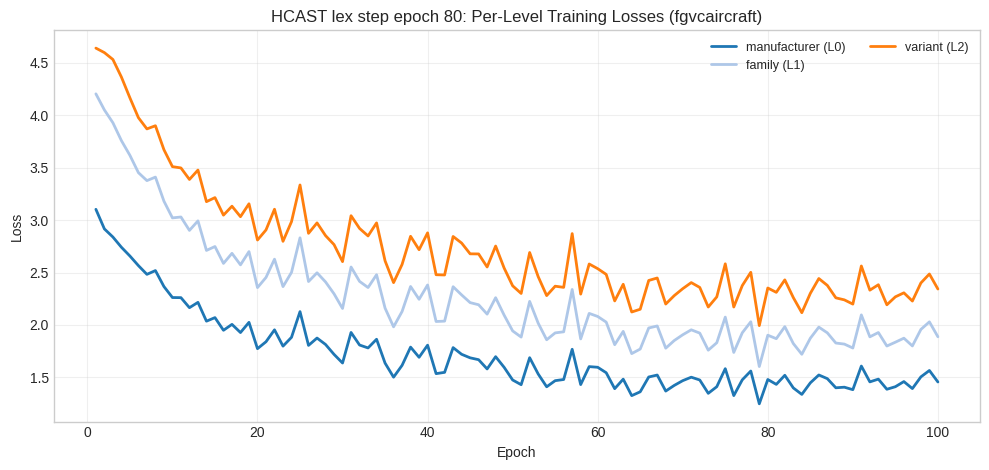

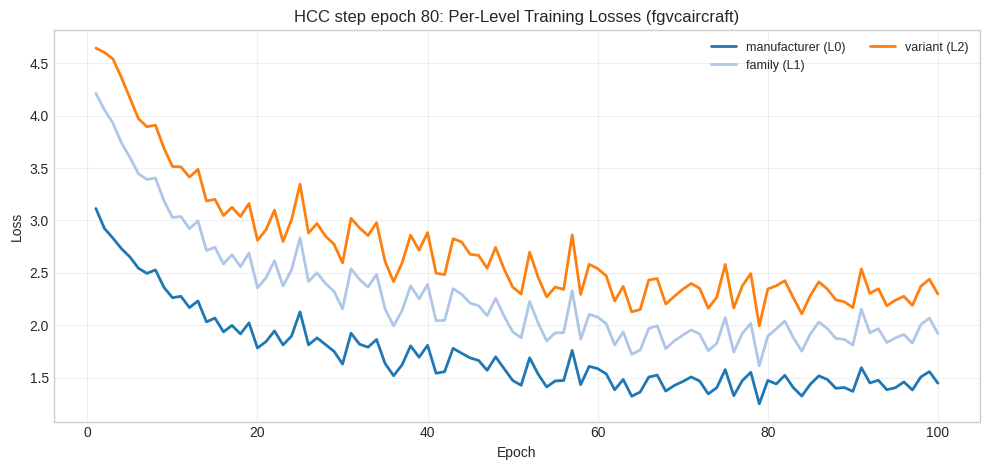

In [37]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

- Standard views are organized by subsets: `t3t2t1`, `t3`, `t2t1`, `t2`, and `t1`.
- Pre-gradient norms include:
  - `t3t2t1`: coarse
  - `t3`: coarse
  - `t2t1`: coarse, mid
  - `t2`: coarse, mid
  - `t1`: coarse, mid, fine
- Gradient cosines shown: `cos_mid_coarse`, `cos_fine_coarse`, `cos_fine_mid` (pairwise, trunk-agnostic overlaps).
- Parameter norms/movement are shown on the same trunk subsets (`t3t2t1/t3/t2t1/t2/t1`).
- In lex mode, `post_grad_*` mirrors pre-gradient keys and a dedicated pre-vs-post overlay is plotted.


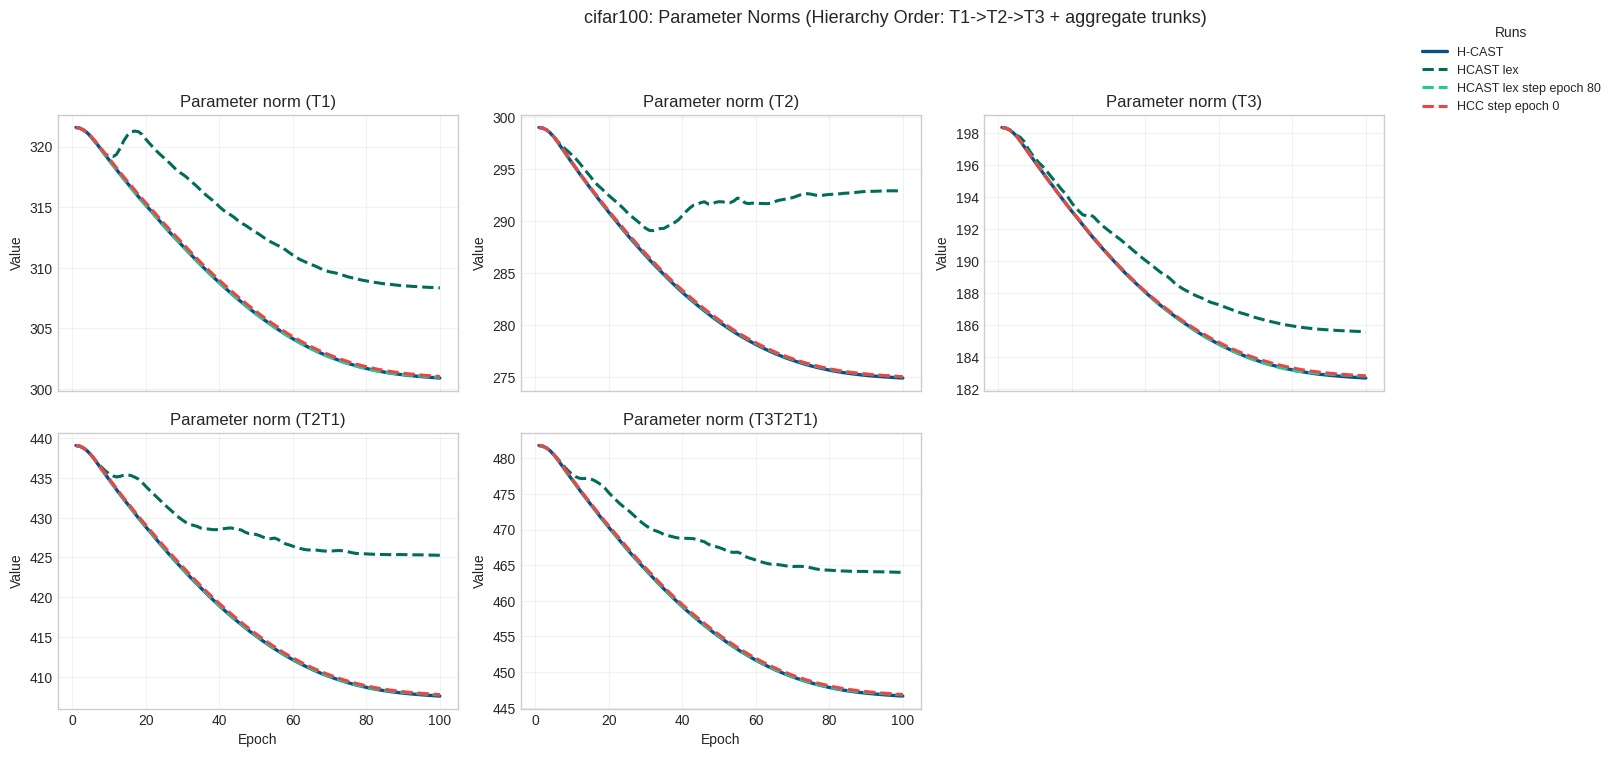

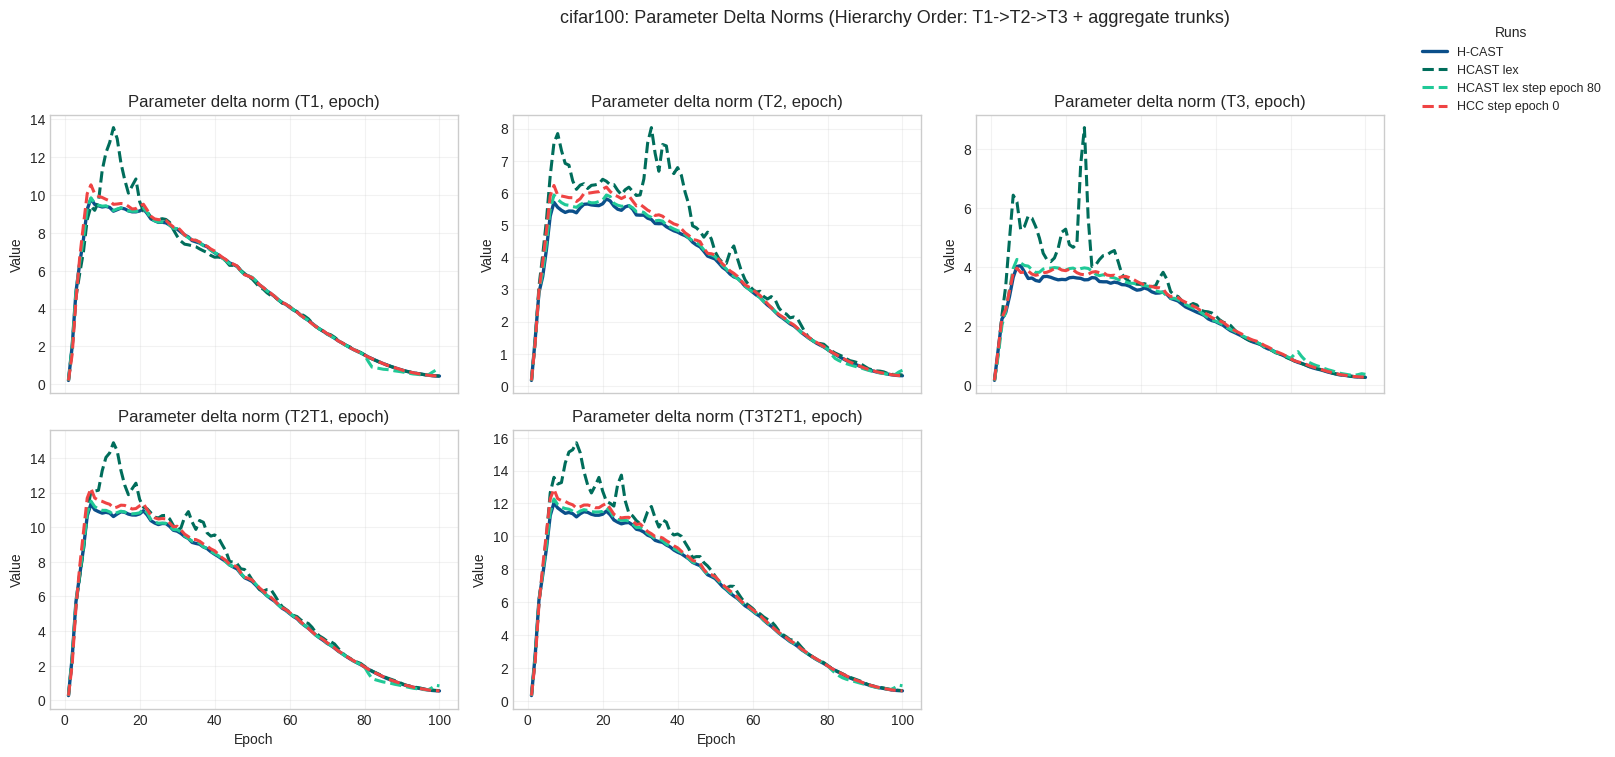

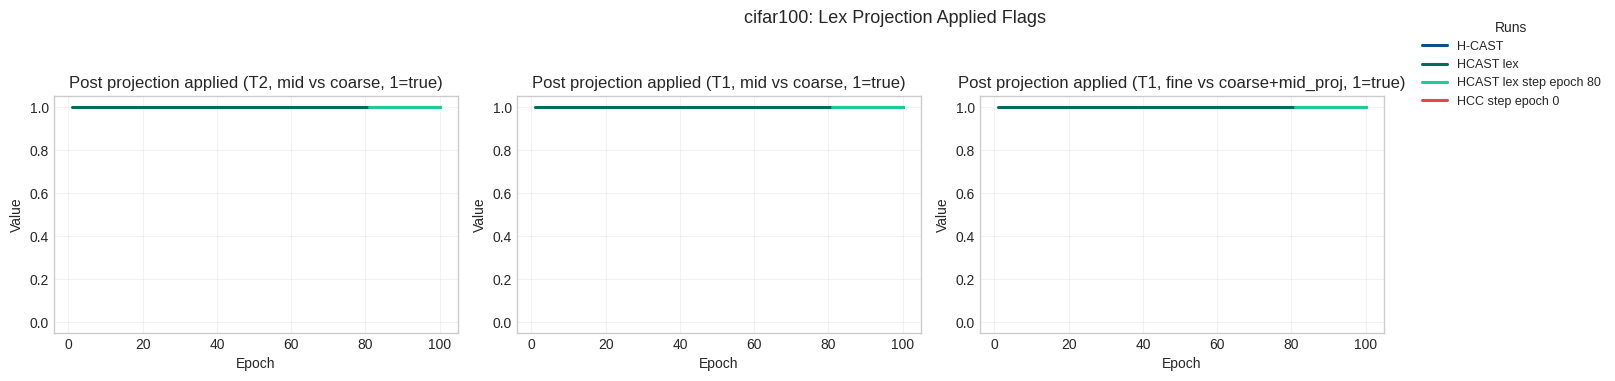

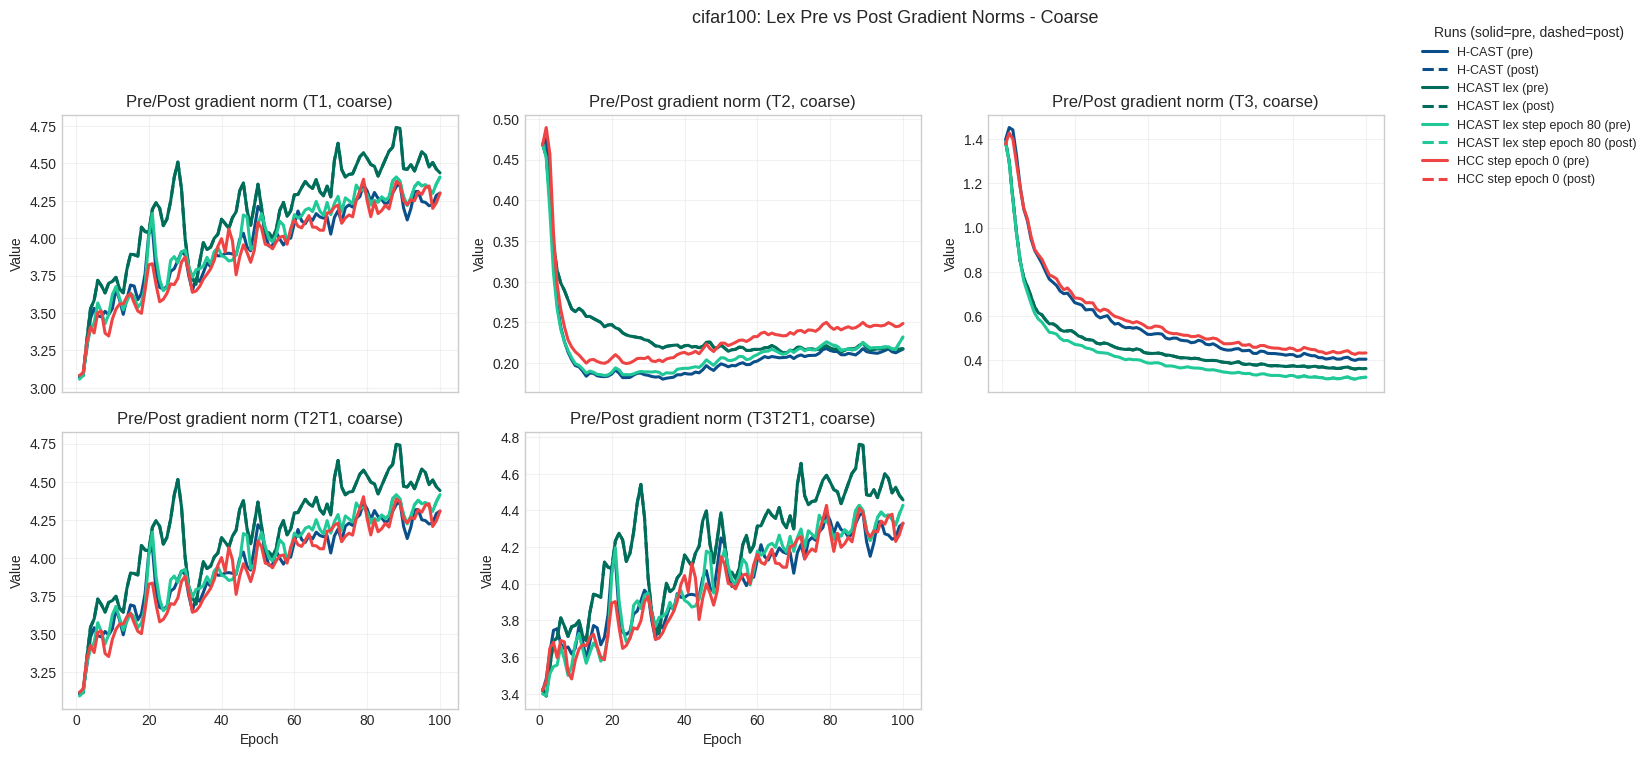

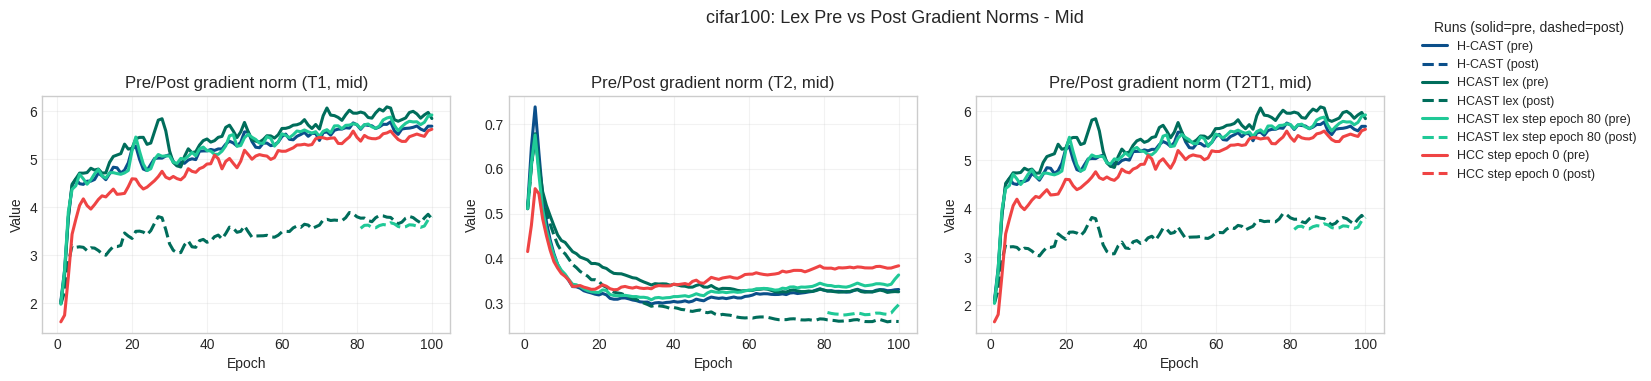

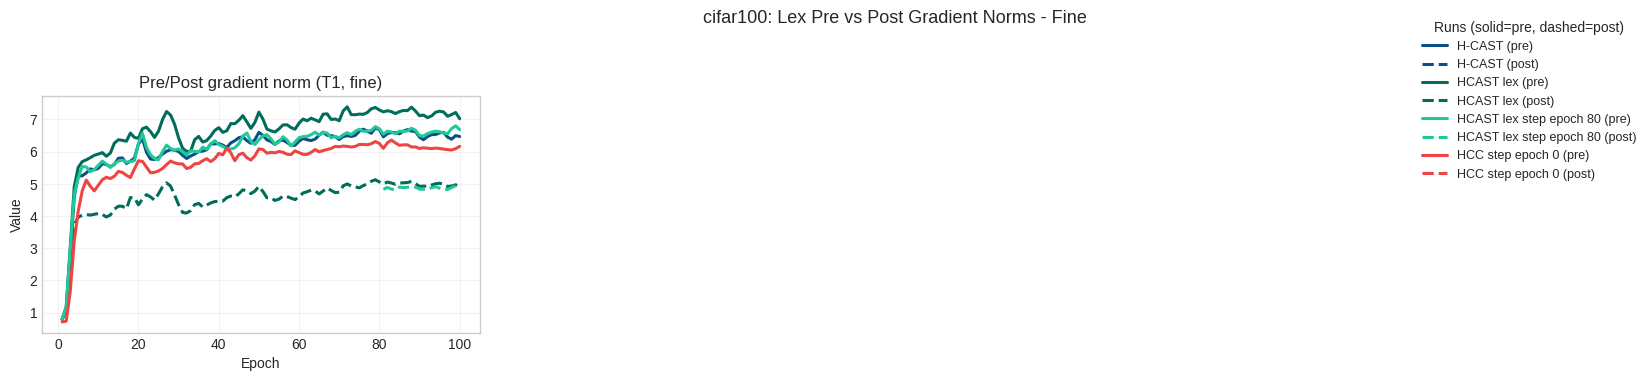

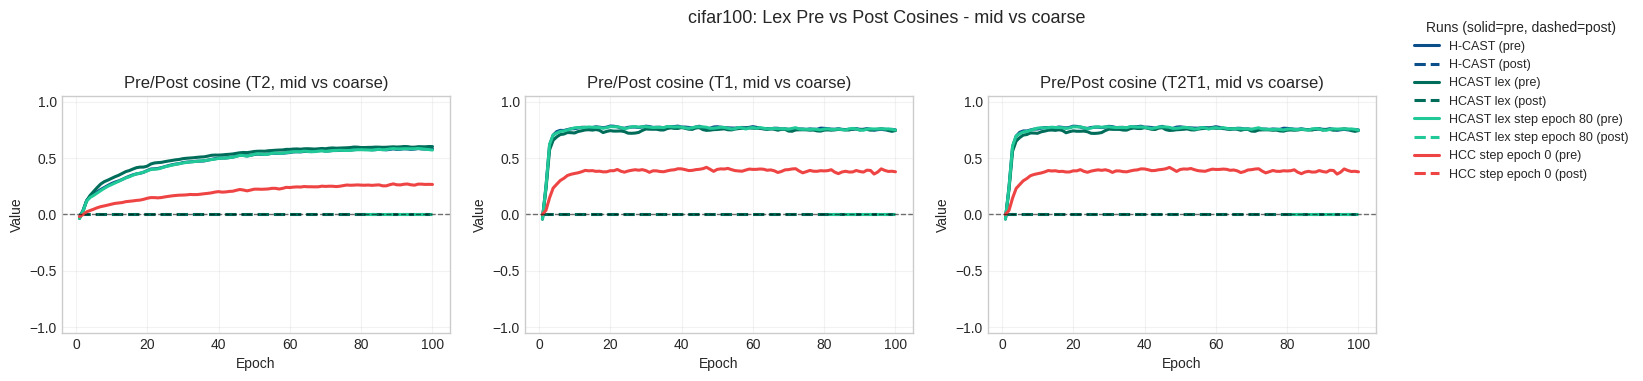

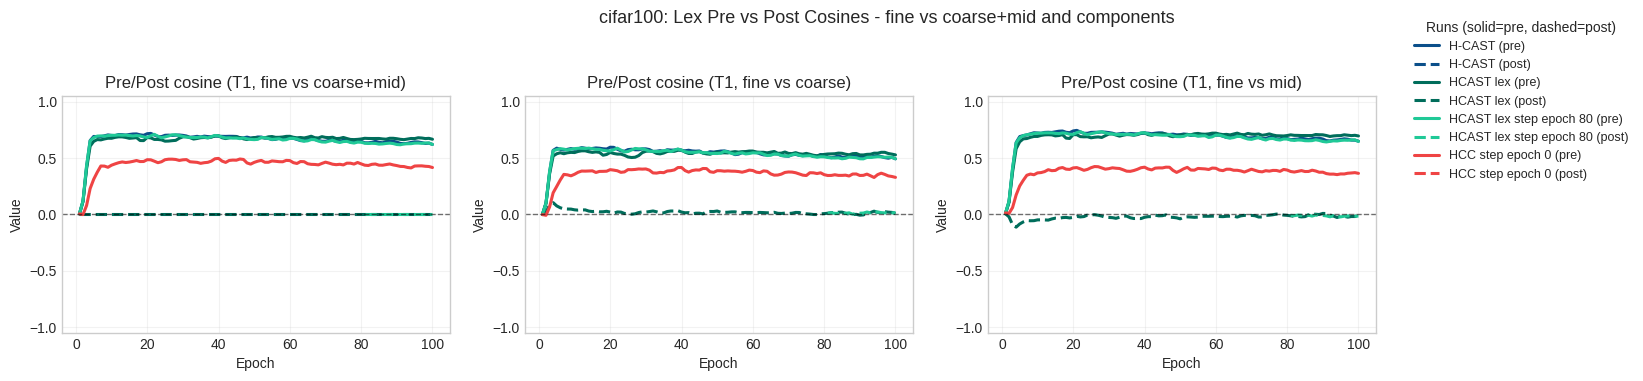

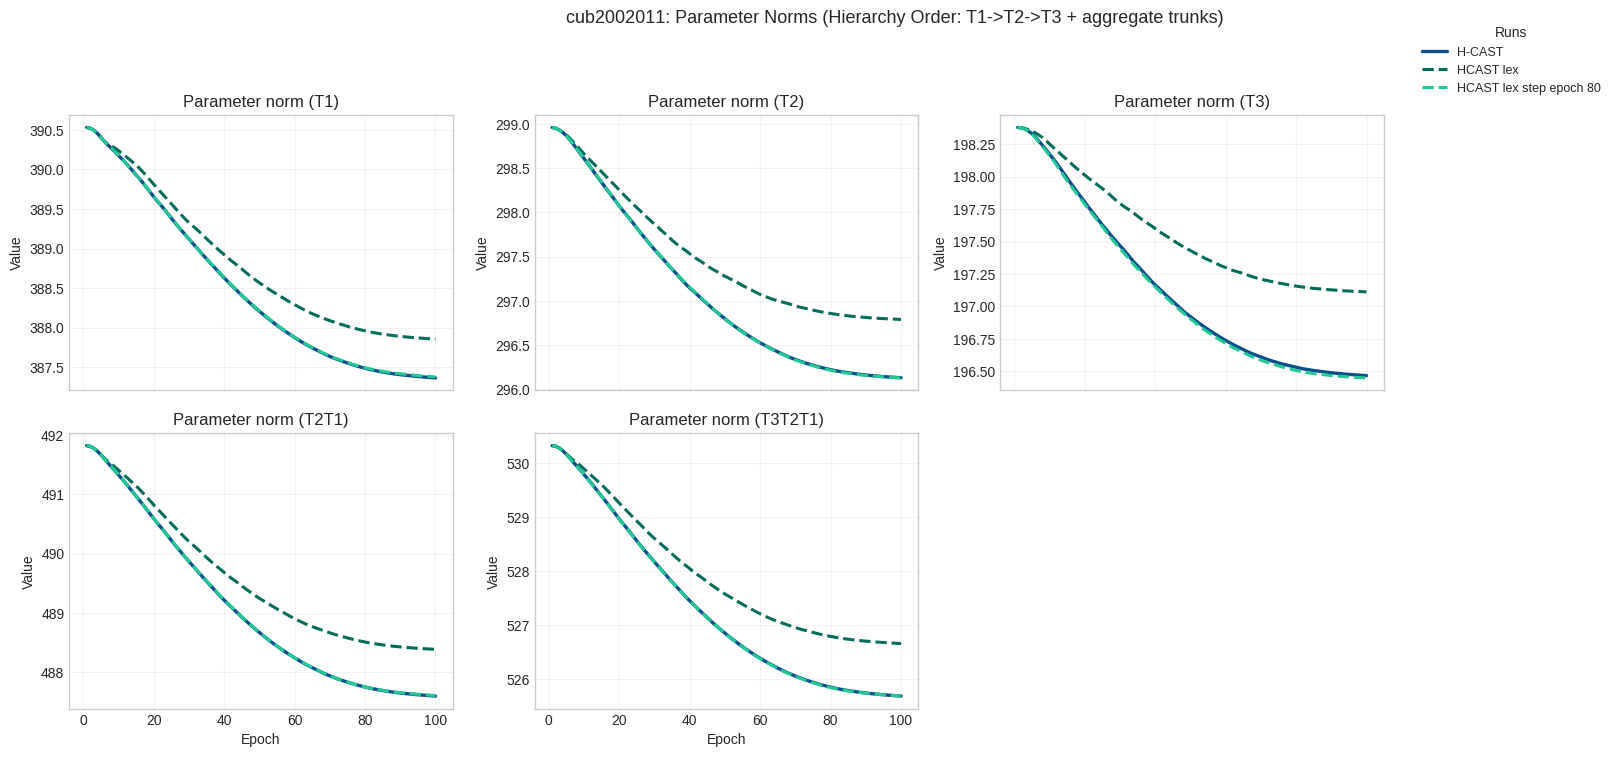

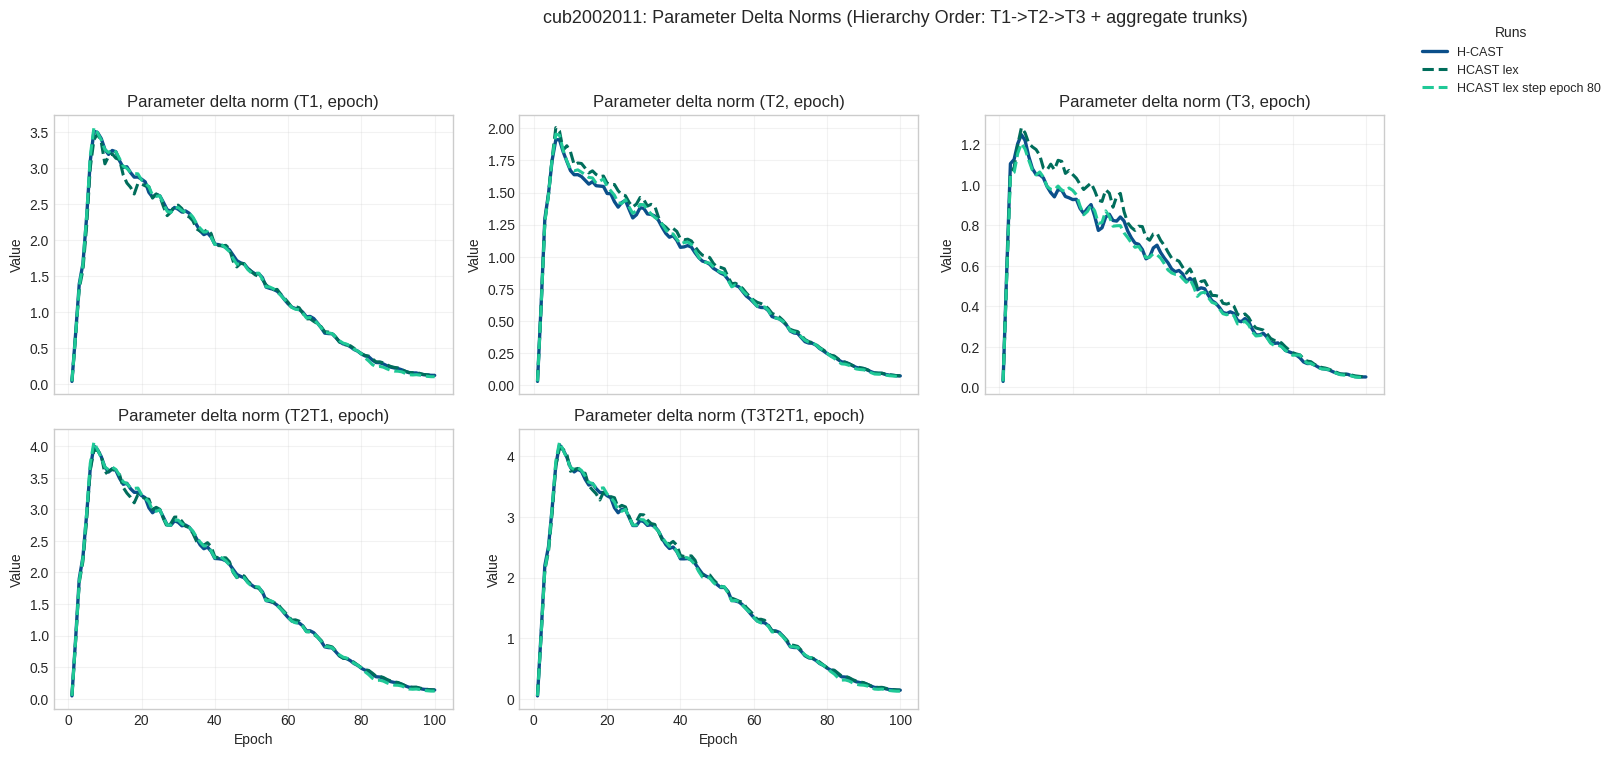

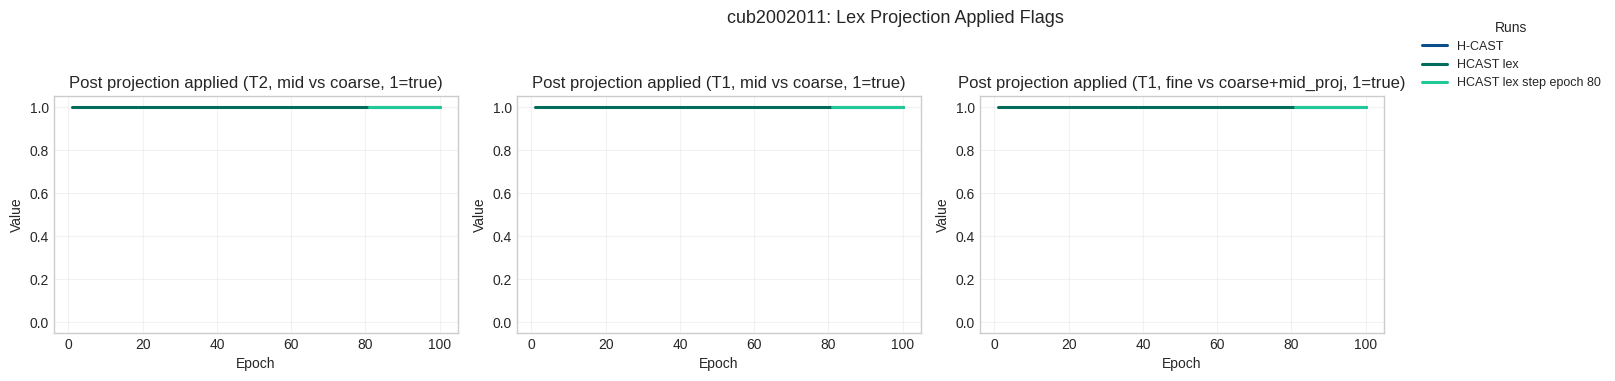

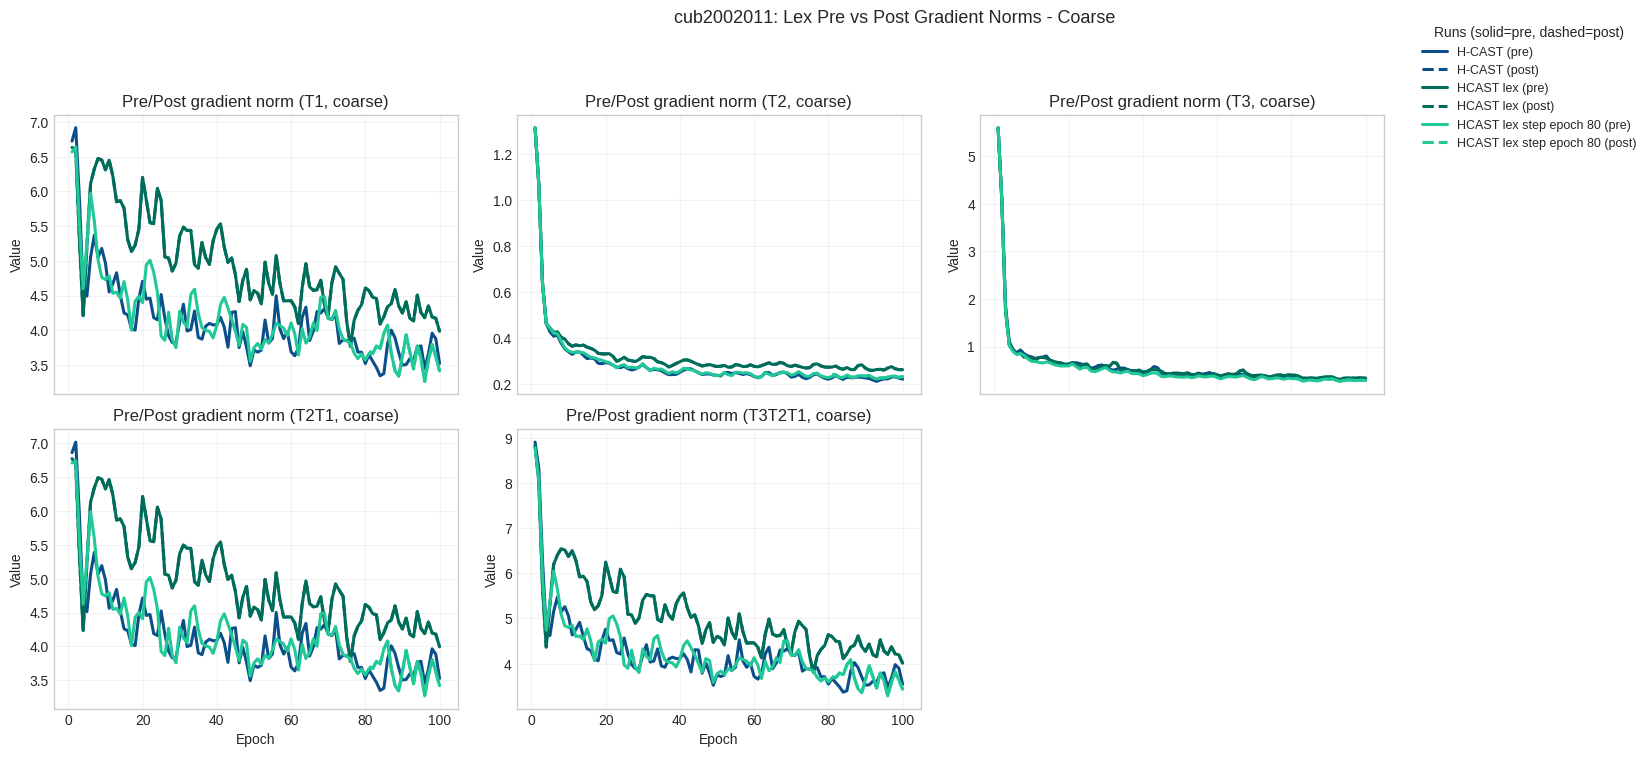

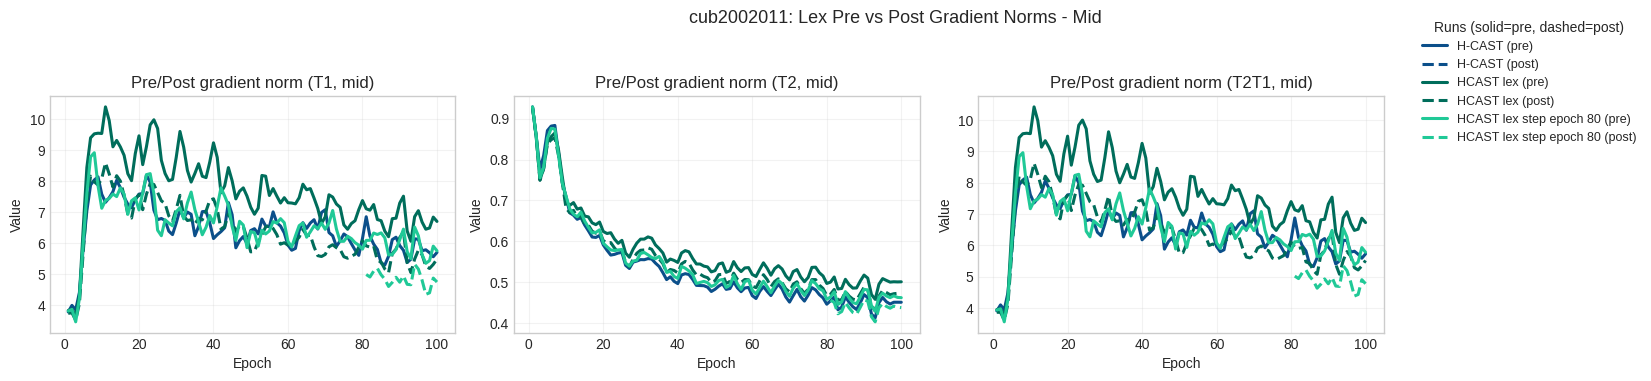

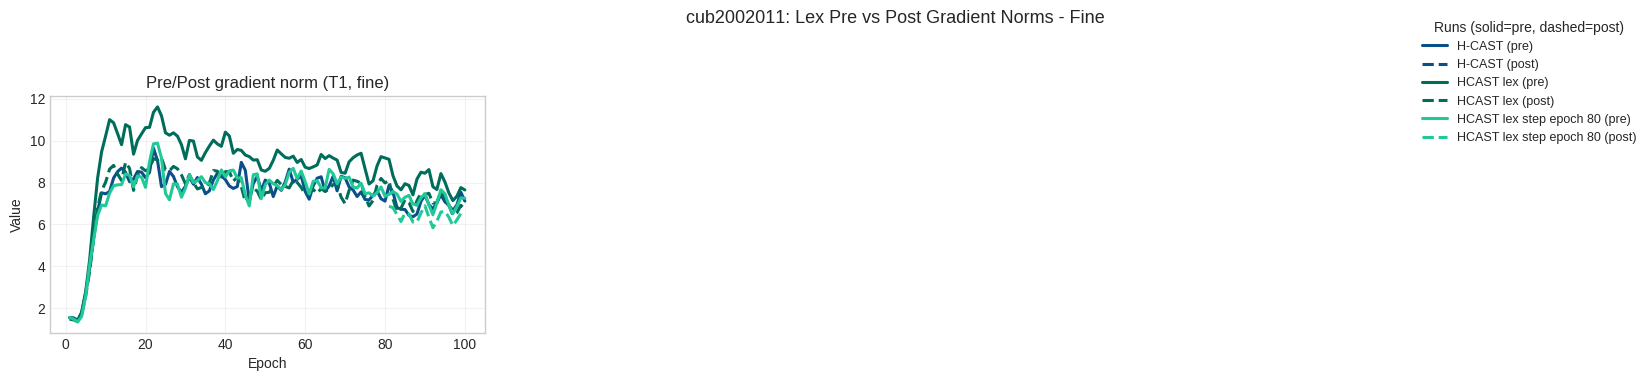

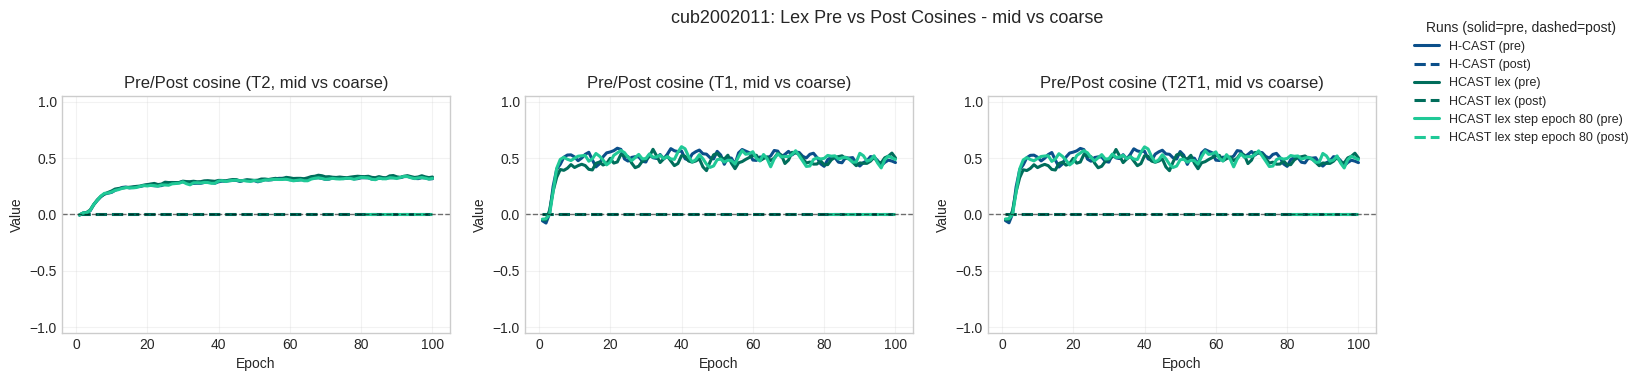

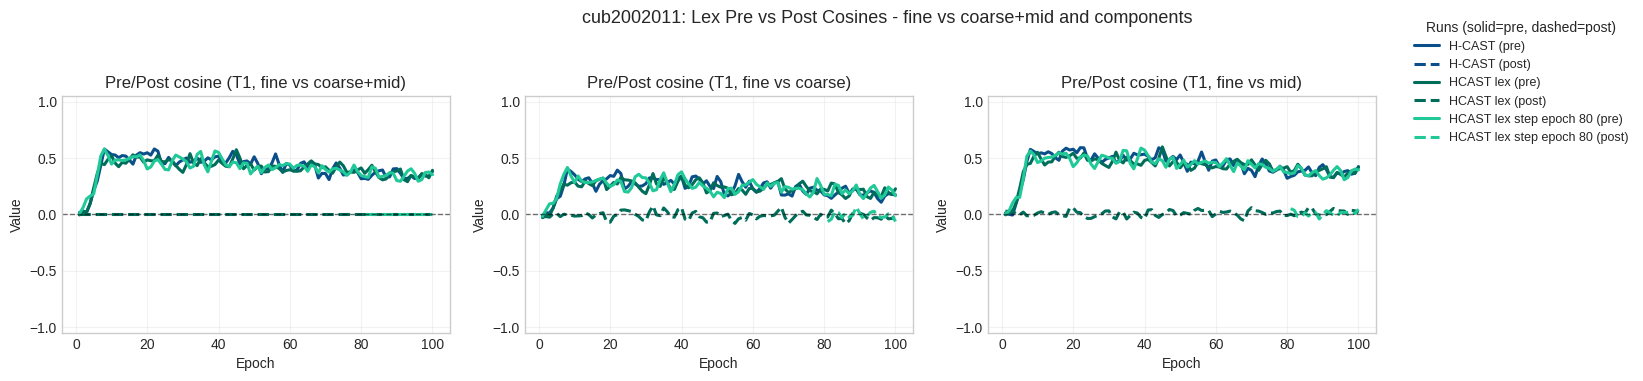

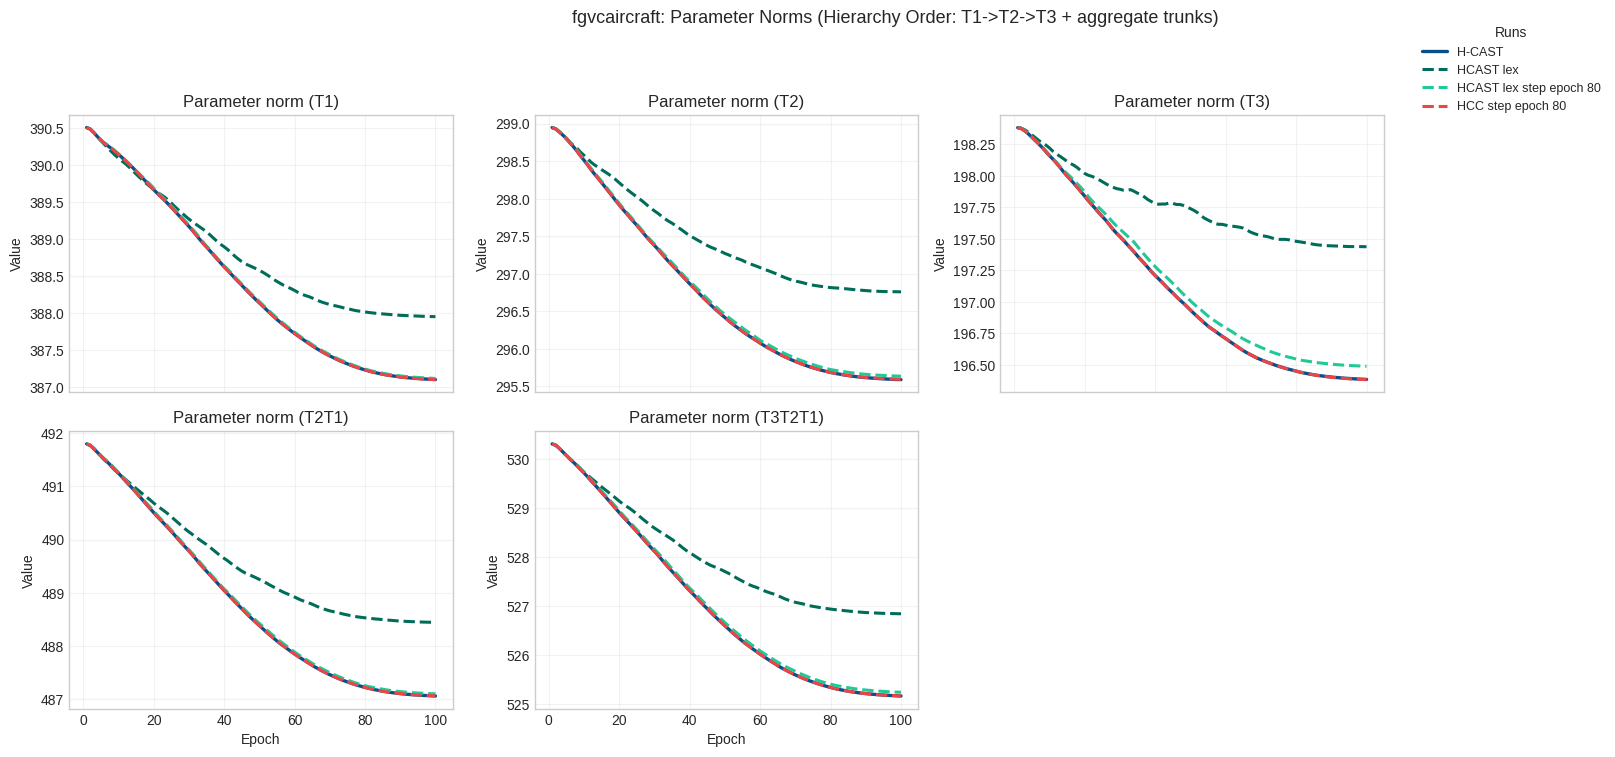

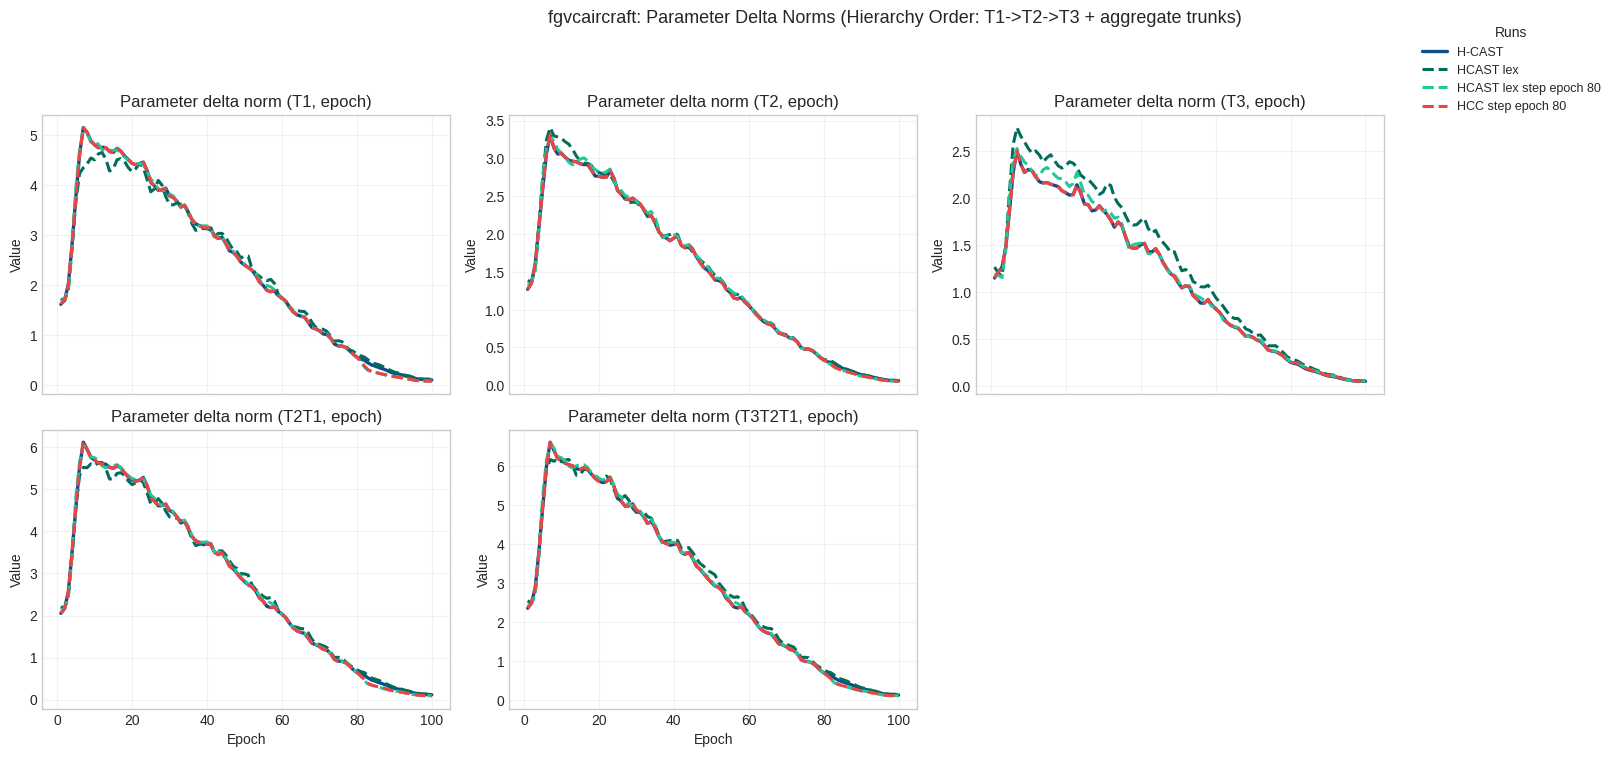

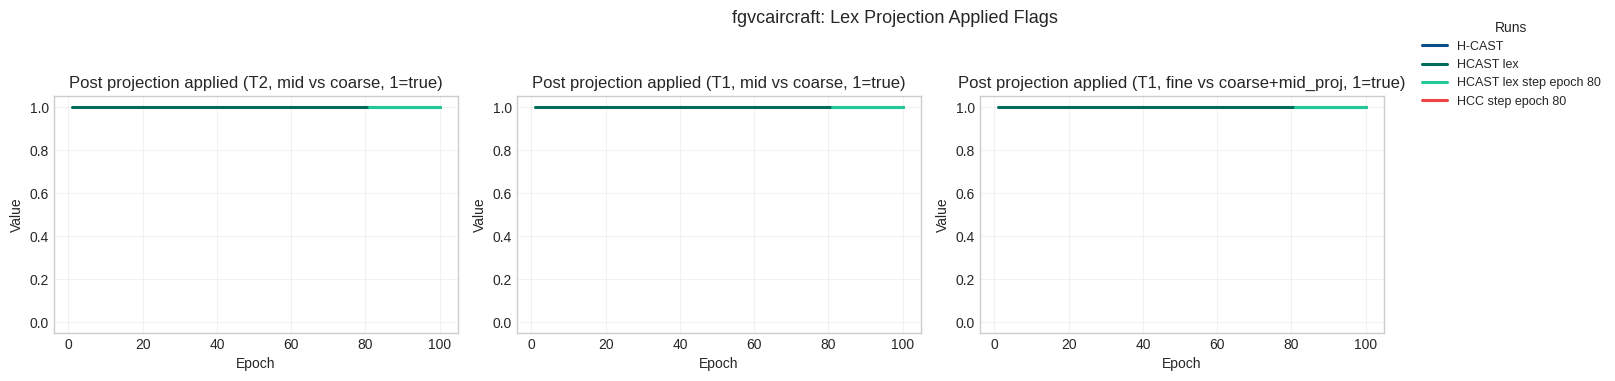

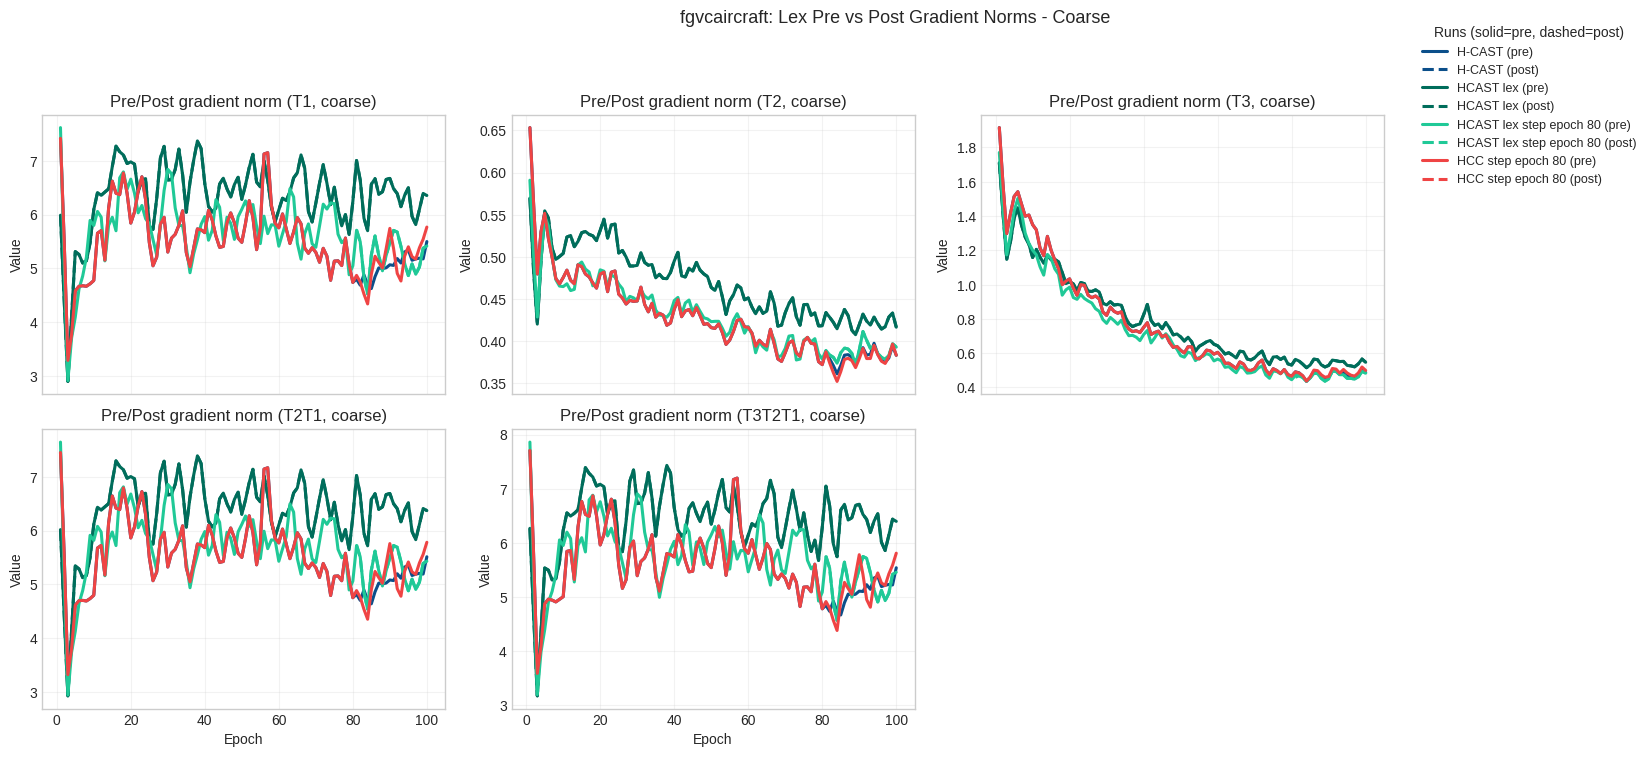

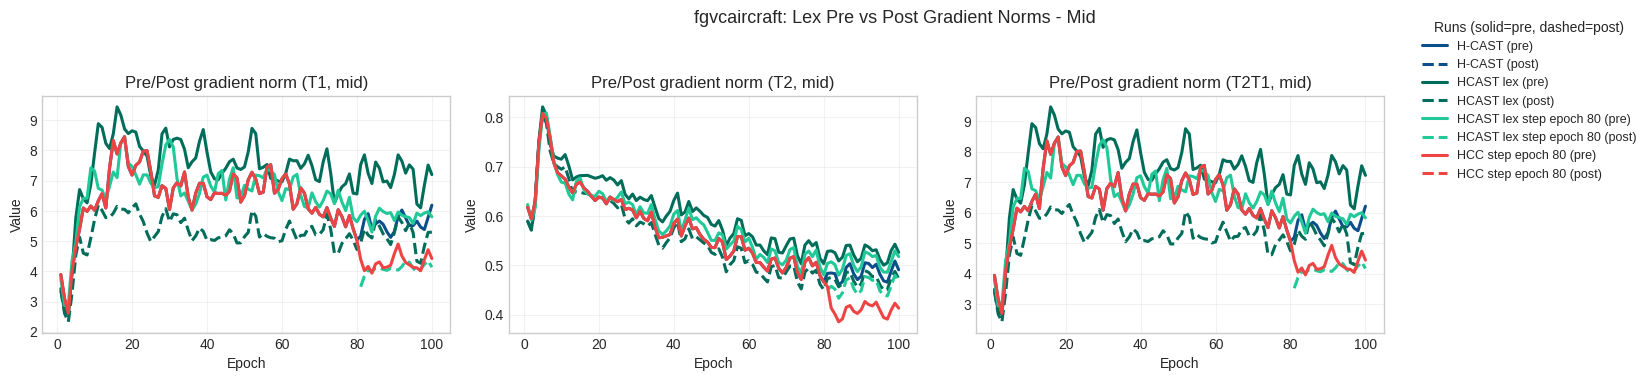

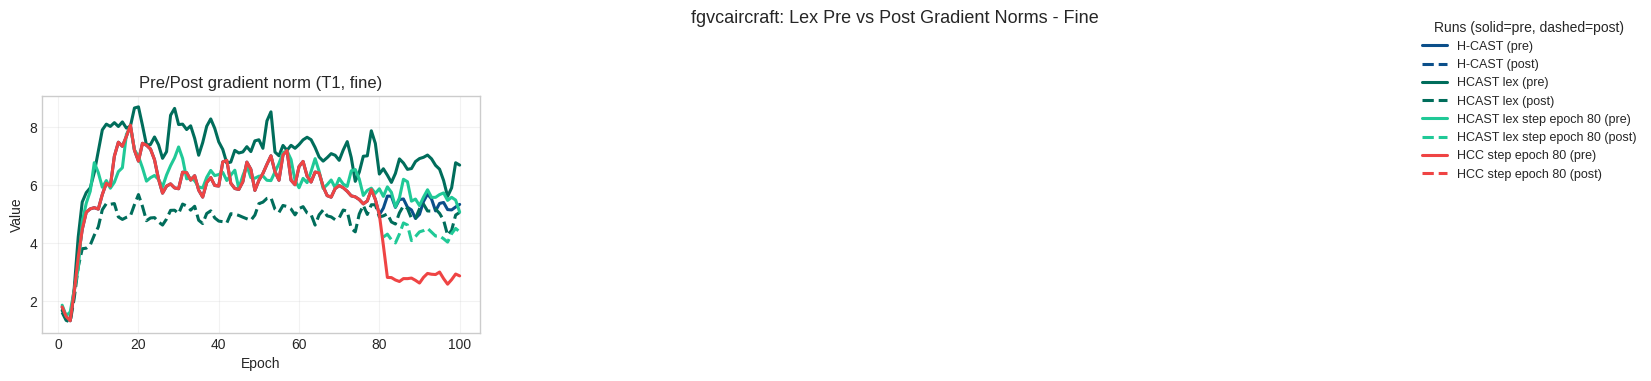

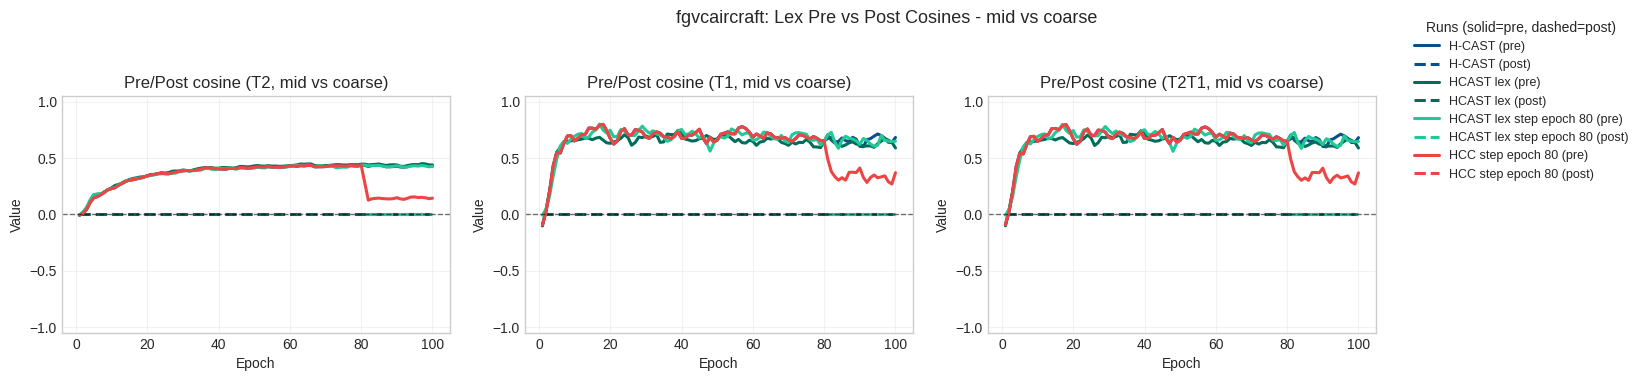

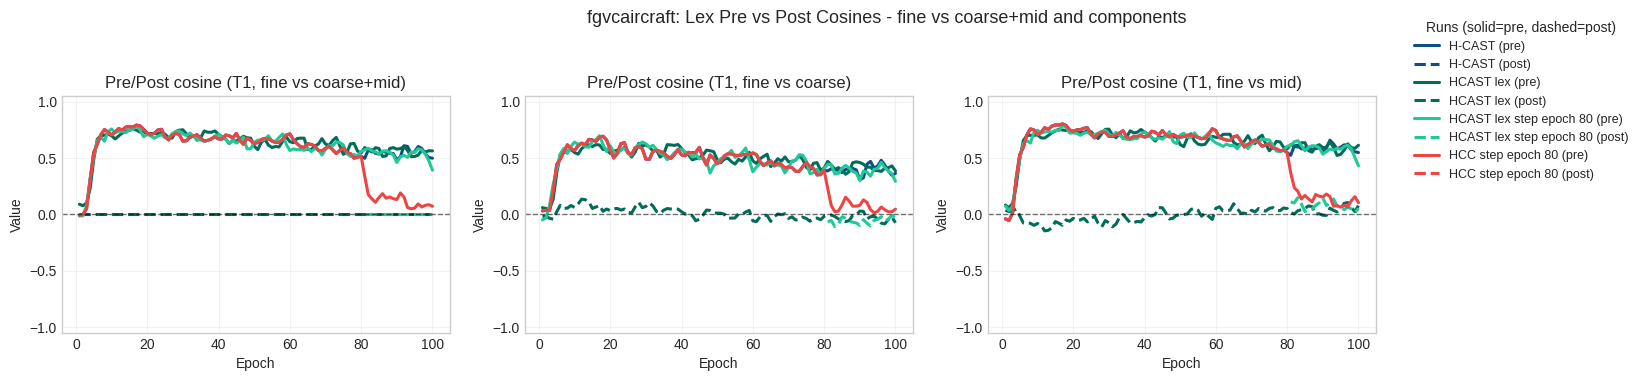

In [38]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

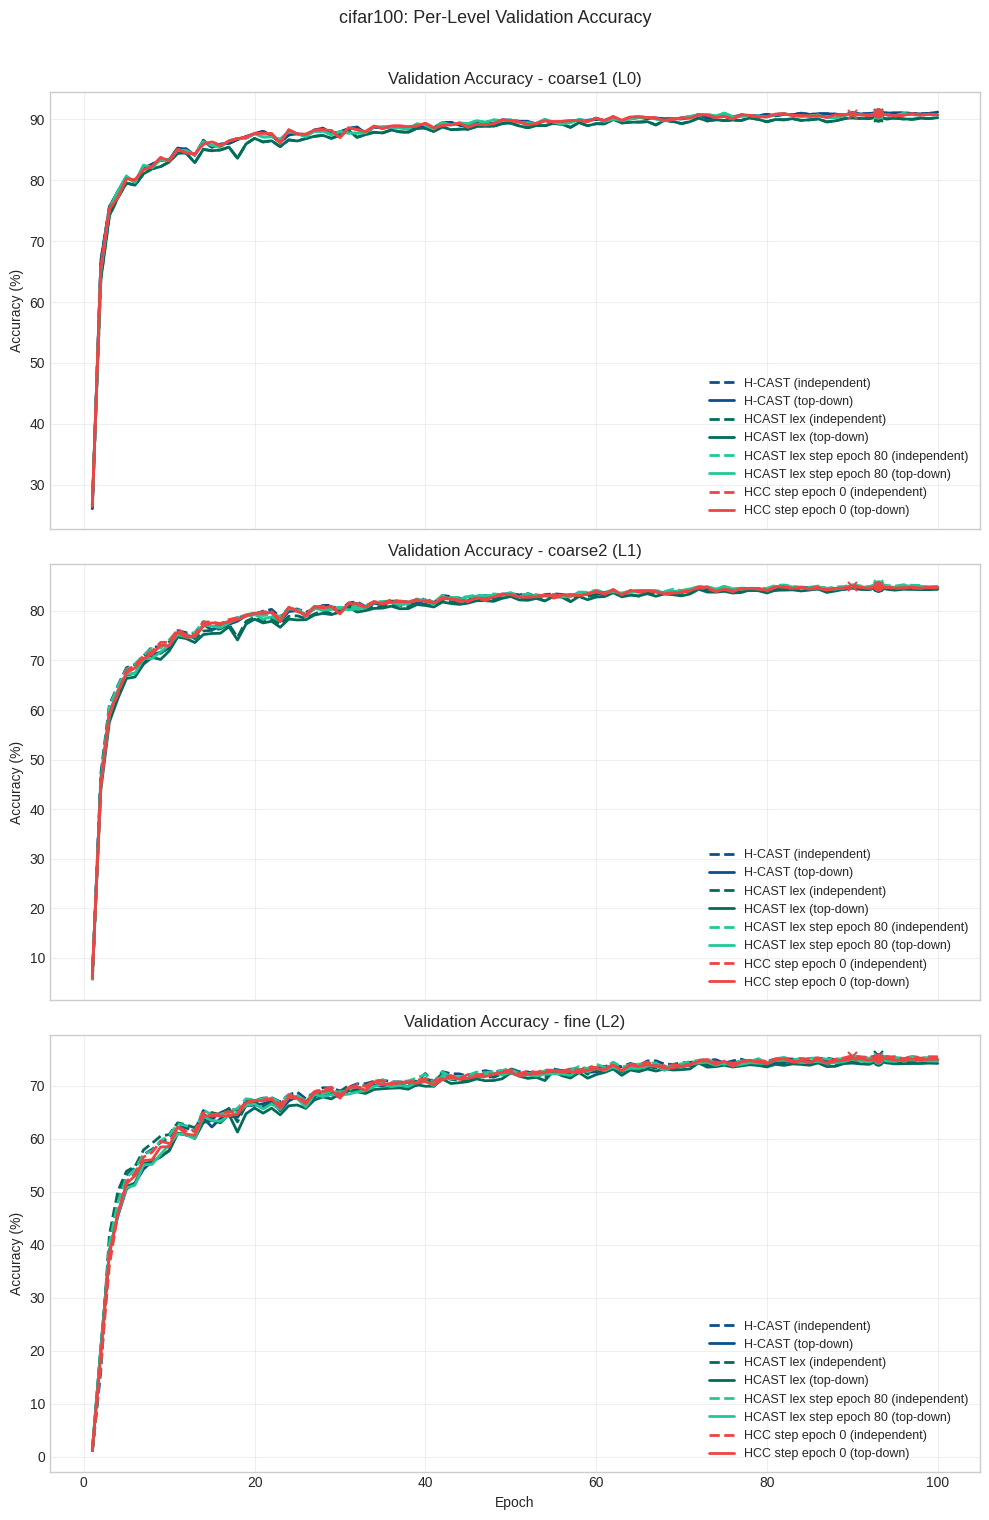

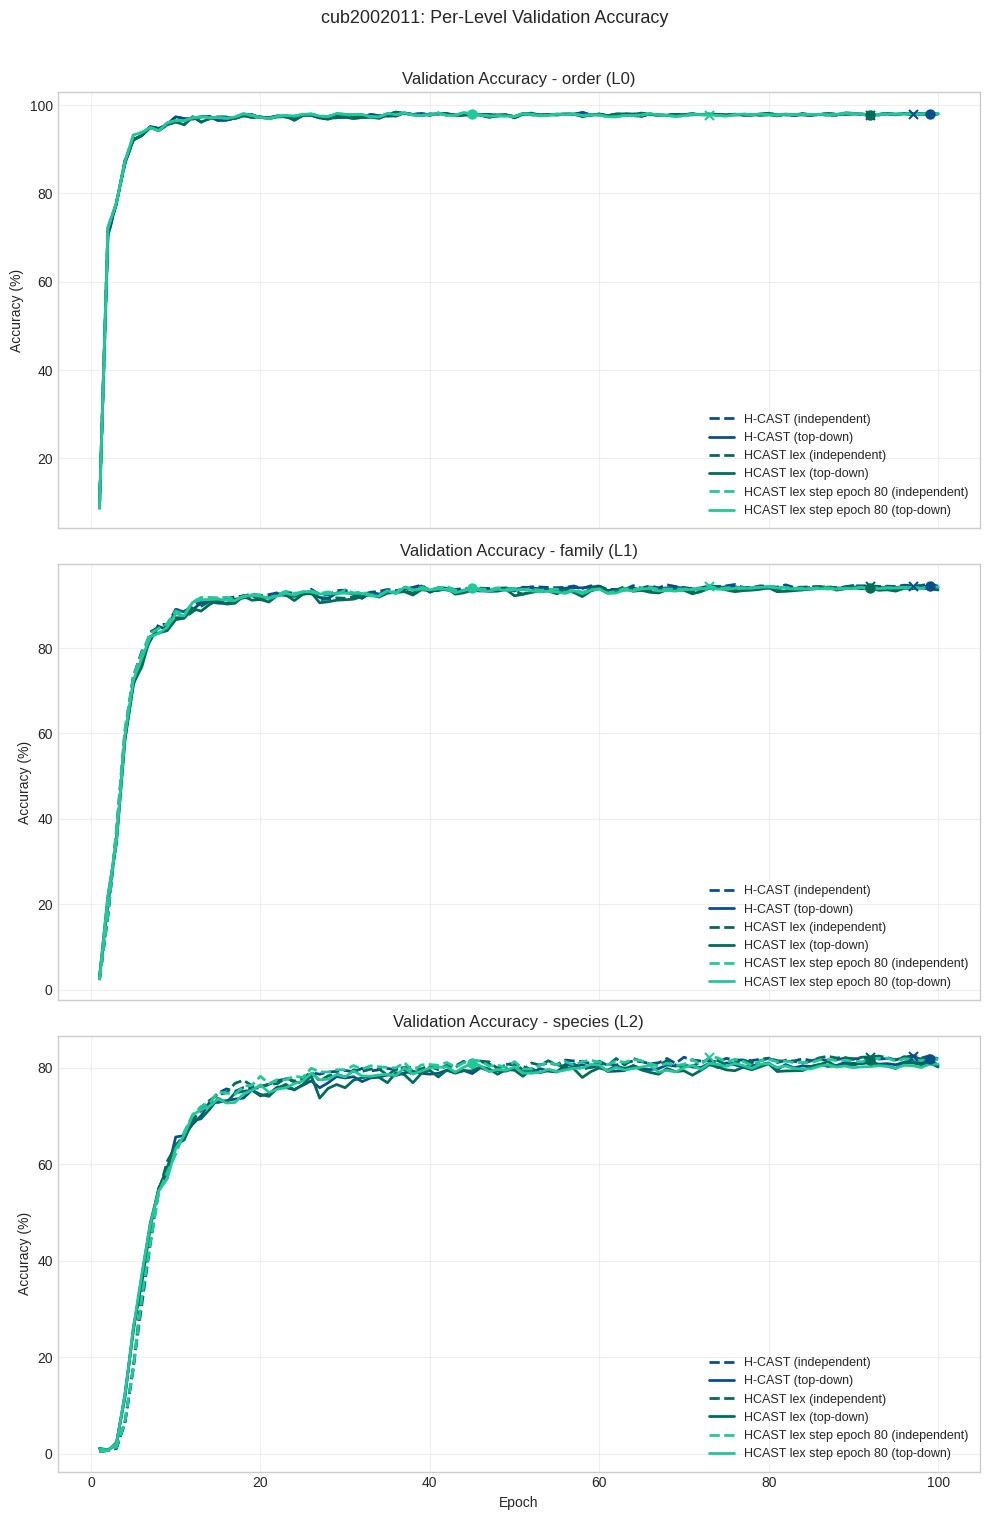

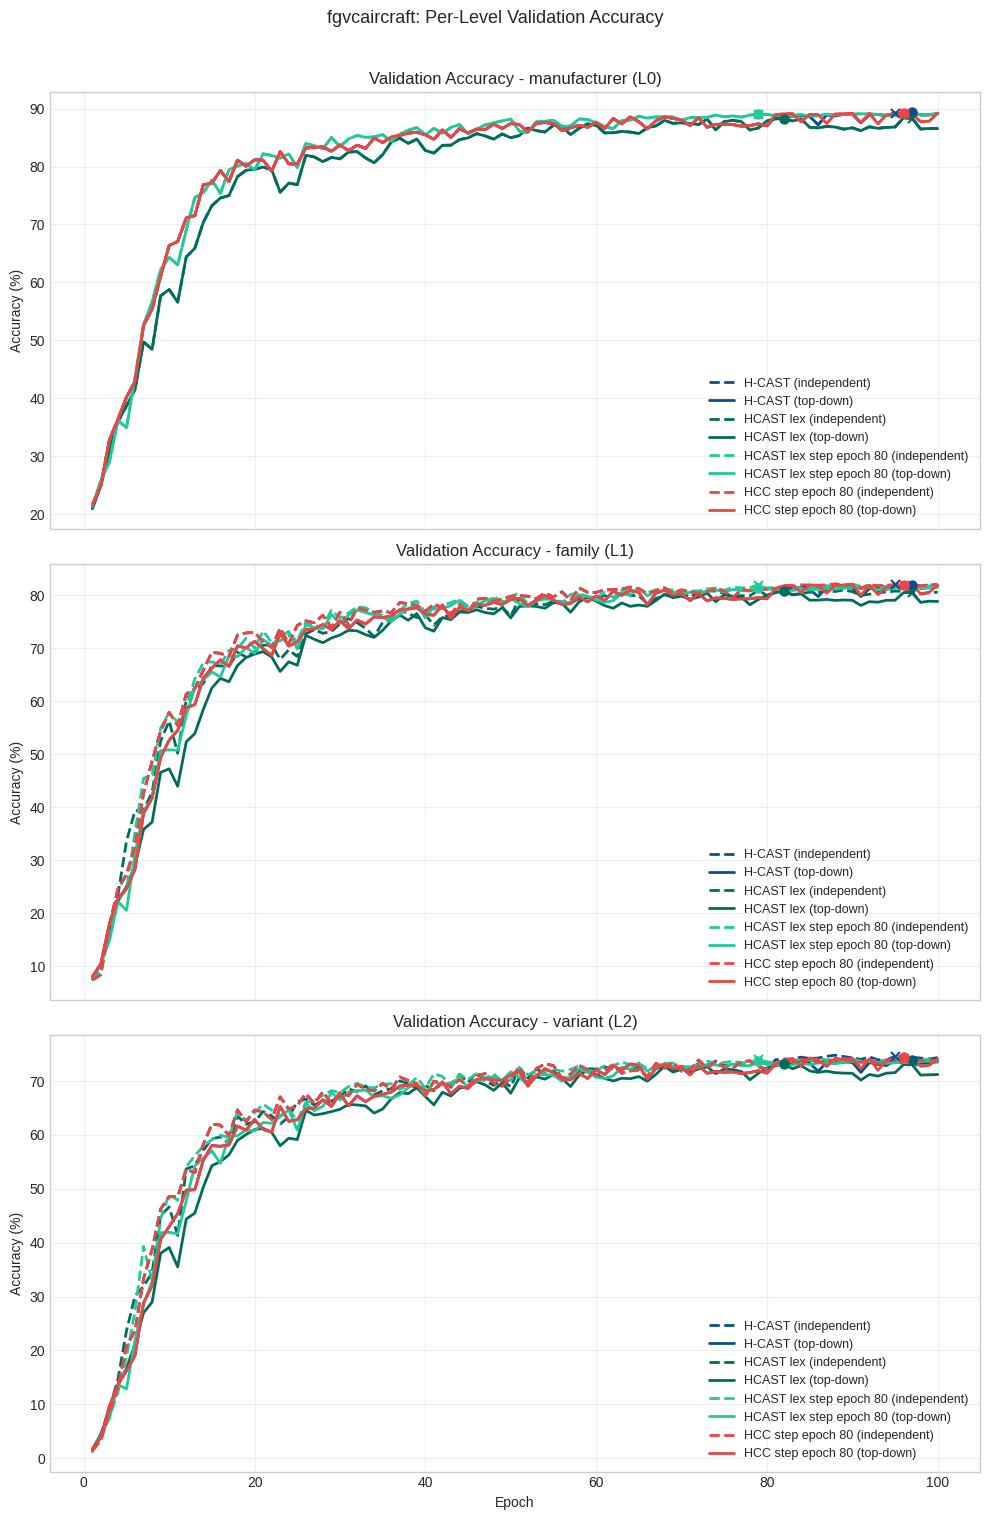

In [39]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset.

In [40]:
analysis.show_final_test_tables()


### Dataset: `cifar100`
Baseline run: **H-CAST**

| Metric | H-CAST | HCAST lex | HCAST lex step epoch 80 | HCC step epoch 0 |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 93/93 | 93/93 | 93/93 | 93/90 |
| FPA independent ↑ | 72.39% | **72.80% (+0.41 pp)** | 72.37% (-0.02 pp) | <u>72.62% (+0.22 pp)</u> |
| FPA top-down ↑ | 74.28% | <u>74.51% (+0.23 pp)</u> | 74.32% (+0.04 pp) | **74.86% (+0.59 pp)** |
| wAP independent ↑ | <u>77.63%</u> | 77.30% (-0.32 pp) | 77.48% (-0.15 pp) | **77.69% (+0.06 pp)** |
| wAP top-down ↑ | 76.91% | <u>77.07% (+0.17 pp)</u> | 76.95% (+0.05 pp) | **77.40% (+0.50 pp)** |
| TICE independent ↓ | <u>8.32%</u> | **6.54% (-1.78 pp)** | 8.35% (+0.03 pp) | 8.78% (+0.46 pp) |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.059 | **1.052 (-0.007)** | <u>1.058 (-0.001)</u> | 1.070 (+0.011) |
| AHD top-down ↓ | 1.011 | 1.010 (-0.001) | <u>1.006 (-0.005)</u> | **0.994 (-0.017)** |
| Acc independent coarse1 (L0) ↑ | <u>90.59%</u> | 90.46% (-0.13 pp) | **90.74% (+0.16 pp)** | 90.20% (-0.39 pp) |
| Acc top-down coarse1 (L0) ↑ | <u>90.59%</u> | 90.46% (-0.13 pp) | **90.74% (+0.16 pp)** | <u>90.59% (+0.00 pp)</u> |
| Acc independent coarse2 (L1) ↑ | <u>84.59%</u> | **84.69% (+0.10 pp)** | 84.45% (-0.14 pp) | 84.22% (-0.37 pp) |
| Acc top-down coarse2 (L1) ↑ | 84.58% | 84.53% (-0.05 pp) | <u>84.63% (+0.05 pp)</u> | **84.83% (+0.25 pp)** |
| Acc independent fine (L2) ↑ | <u>75.20%</u> | 74.78% (-0.42 pp) | 75.02% (-0.18 pp) | **75.38% (+0.19 pp)** |
| Acc top-down fine (L2) ↑ | 74.28% | <u>74.51% (+0.23 pp)</u> | 74.32% (+0.04 pp) | **74.86% (+0.59 pp)** |

### Dataset: `cub2002011`
Baseline run: **H-CAST**

| Metric | H-CAST | HCAST lex | HCAST lex step epoch 80 |
|---|---:|---:|---:|
| Best epoch (TD/Ind) | 99/97 | 92/92 | 45/73 |
| FPA independent ↑ | <u>79.44%</u> | **79.56% (+0.12 pp)** | 79.04% (-0.41 pp) |
| FPA top-down ↑ | <u>80.96%</u> | **81.08% (+0.13 pp)** | 79.94% (-1.02 pp) |
| wAP independent ↑ | <u>84.21%</u> | **84.38% (+0.18 pp)** | 84.02% (-0.19 pp) |
| wAP top-down ↑ | <u>83.73%</u> | **83.84% (+0.11 pp)** | 82.87% (-0.87 pp) |
| TICE independent ↓ | **5.85%** | 6.39% (+0.54 pp) | <u>6.35% (+0.49 pp)</u> |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.582</u> | **0.582 (-0.000)** | 0.594 (+0.012) |
| AHD top-down ↓ | <u>0.550</u> | **0.546 (-0.005)** | 0.576 (+0.025) |
| Acc independent order (L0) ↑ | 98.13% | <u>98.20% (+0.07 pp)</u> | **98.25% (+0.12 pp)** |
| Acc top-down order (L0) ↑ | 98.08% | <u>98.20% (+0.12 pp)</u> | **98.27% (+0.19 pp)** |
| Acc independent family (L1) ↑ | **93.61%** | <u>93.47% (-0.14 pp)</u> | 93.39% (-0.22 pp) |
| Acc top-down family (L1) ↑ | **93.44%** | <u>93.44% (-0.00 pp)</u> | 93.01% (-0.43 pp) |
| Acc independent species (L2) ↑ | <u>81.51%</u> | **81.76% (+0.24 pp)** | 81.31% (-0.20 pp) |
| Acc top-down species (L2) ↑ | <u>80.96%</u> | **81.08% (+0.13 pp)** | 79.94% (-1.02 pp) |

### Dataset: `fgvcaircraft`
Baseline run: **H-CAST**

| Metric | H-CAST | HCAST lex | HCAST lex step epoch 80 | HCC step epoch 80 |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 97/95 | 82/97 | 79/79 | 96/96 |
| FPA independent ↑ | 69.24% | <u>69.67% (+0.42 pp)</u> | 68.68% (-0.56 pp) | **71.12% (+1.87 pp)** |
| FPA top-down ↑ | 72.31% | <u>73.29% (+0.98 pp)</u> | 72.11% (-0.20 pp) | **73.96% (+1.65 pp)** |
| wAP independent ↑ | **78.55%** | 77.85% (-0.70 pp) | 77.80% (-0.75 pp) | <u>78.49% (-0.06 pp)</u> |
| wAP top-down ↑ | 77.23% | <u>78.14% (+0.92 pp)</u> | 77.21% (-0.02 pp) | **78.79% (+1.57 pp)** |
| TICE independent ↓ | 13.68% | <u>12.98% (-0.70 pp)</u> | 14.16% (+0.47 pp) | **11.08% (-2.60 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.289 | <u>1.259 (-0.030)</u> | 1.300 (+0.011) | **1.196 (-0.093)** |
| AHD top-down ↓ | 1.208 | <u>1.157 (-0.051)</u> | 1.210 (+0.002) | **1.118 (-0.090)** |
| Acc independent manufacturer (L0) ↑ | 87.35% | <u>87.89% (+0.54 pp)</u> | 87.13% (-0.22 pp) | **88.67% (+1.32 pp)** |
| Acc top-down manufacturer (L0) ↑ | 87.38% | <u>88.00% (+0.62 pp)</u> | 87.13% (-0.25 pp) | **88.67% (+1.29 pp)** |
| Acc independent family (L1) ↑ | <u>81.38%</u> | 80.74% (-0.64 pp) | **81.97% (+0.59 pp)** | 81.36% (-0.03 pp) |
| Acc top-down family (L1) ↑ | 79.90% | <u>80.85% (+0.95 pp)</u> | 80.23% (+0.33 pp) | **81.47% (+1.57 pp)** |
| Acc independent variant (L2) ↑ | **73.93%** | 72.82% (-1.12 pp) | 72.09% (-1.85 pp) | <u>73.43% (-0.50 pp)</u> |
| Acc top-down variant (L2) ↑ | 72.31% | <u>73.29% (+0.98 pp)</u> | 72.11% (-0.20 pp) | **73.96% (+1.65 pp)** |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
